In [1]:
#These corrected cells were reconstructed from the uploaded notebook HTML export and keep the same main concepts and processing flow. The key fixes are:

#- removed stale-variable collisions between Step 11 and Step 12
#- made Step 11 the single source of truth for ensemble/VPG/SDPPG
#- added ensemble metadata needed for exact re-plotting
#- made Step 13 save the exact Step 11 plotted waveforms and time axes
#- added consistency checks before saving
#- kept your original filtering / normalization / SQI / ensemble concepts

#---

## Cell 319 — STEP 1: MASTER CONFIGURATION

#```python
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os
import tkinter as tk
from tkinter import filedialog

# ==========================================
# 🔧 STEP 1: MASTER CONFIGURATION
# ==========================================

FOLDER_PATH   = r'C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\03_Windowed'
FS            = 400.0
USE_FULL_FILE = True  # True = process whole CSV

# ✅ POP-UP FILE PICKER (more notebook-safe)
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

FILENAME = filedialog.askopenfilename(
    initialdir=FOLDER_PATH,
    title="Select PPG CSV File",
    filetypes=[("CSV Files", "*.csv")]
)

root.destroy()

if not FILENAME:
    raise ValueError("❌ No file selected. Please choose a CSV file.")

print(f"📂 Selected File: {os.path.basename(FILENAME)}")

# 2) ✂️ DATA SELECTION
# If SAMPLE_END == 0, it will be auto-set after loading df
SAMPLE_START = 0
SAMPLE_END   = 0

# 3) Plotting Settings
SUBPLOT_HEIGHT              = 4.0
TIME_VERTICAL_LINE_INTERVAL = 1.0
FREQ_VERTICAL_LINE_INTERVAL = 1.0

# 4) Validity Thresholds
THRESHOLD_RED = 0
THRESHOLD_IR  = 0

# Spike Removal
SPIKE_ENABLE  = True
KERNEL_SIZE   = 3

# Signal Inversion
INVERT_ENABLE = True

# Low Pass Filter
LP_ENABLE     = True
LP_CUTOFF     = 16.0
LP_ORDER      = 4

# High Pass Filter
HP_ENABLE     = True
HP_CUTOFF     = 0.5
HP_ORDER      = 4

# Savitzky-Golay
SG_ENABLE     = False
SG_WINDOW     = 31
SG_POLY       = 3

# Normalization
NORM_SELECTION = 1  # 1=MinMax, 2=ZScore

# Default ensemble length for Step 11
ENSEMBLE_TARGET_LEN = 220

SQI_LIMITS = {
    'SKEWNESS_MIN': 0.0,   'SKEWNESS_MAX': 2.5,
    'KURTOSIS_MIN': 1.5,   'KURTOSIS_MAX': 7.0,
    'PI_MIN':       0.1,   'PI_MAX':       10.0,
    'SNR_MIN_DB':   5.0,   'SNR_MAX_DB':   25.0,
    'ZCR_MIN':      1.0,   'ZCR_MAX':      4.0
}

def apply_normalization(data, selection=1):
    data = np.asarray(data)
    if data.size == 0:
        return data

    if selection == 1:  # MinMax
        den = np.max(data) - np.min(data)
        if den == 0:
            return np.zeros_like(data)
        return (data - np.min(data)) / den

    elif selection == 2:  # Z-score
        sd = np.std(data)
        if sd == 0:
            return np.zeros_like(data)
        return (data - np.mean(data)) / sd

    return data

print("✅ Configuration Loaded.")
print(f"📌 FS={FS} Hz | Plot Height={SUBPLOT_HEIGHT} inches")
print(f"📏 Grid: Time={TIME_VERTICAL_LINE_INTERVAL}s | Freq={FREQ_VERTICAL_LINE_INTERVAL}Hz")
print(f"🫀 Ensemble Target Length = {ENSEMBLE_TARGET_LEN} samples")

📂 Selected File: abeeha(23-enc-19)v5_Win1.csv
✅ Configuration Loaded.
📌 FS=400.0 Hz | Plot Height=4.0 inches
📏 Grid: Time=1.0s | Freq=1.0Hz
🫀 Ensemble Target Length = 220 samples


✅ Processing Range: 6000 samples (15.00 seconds).


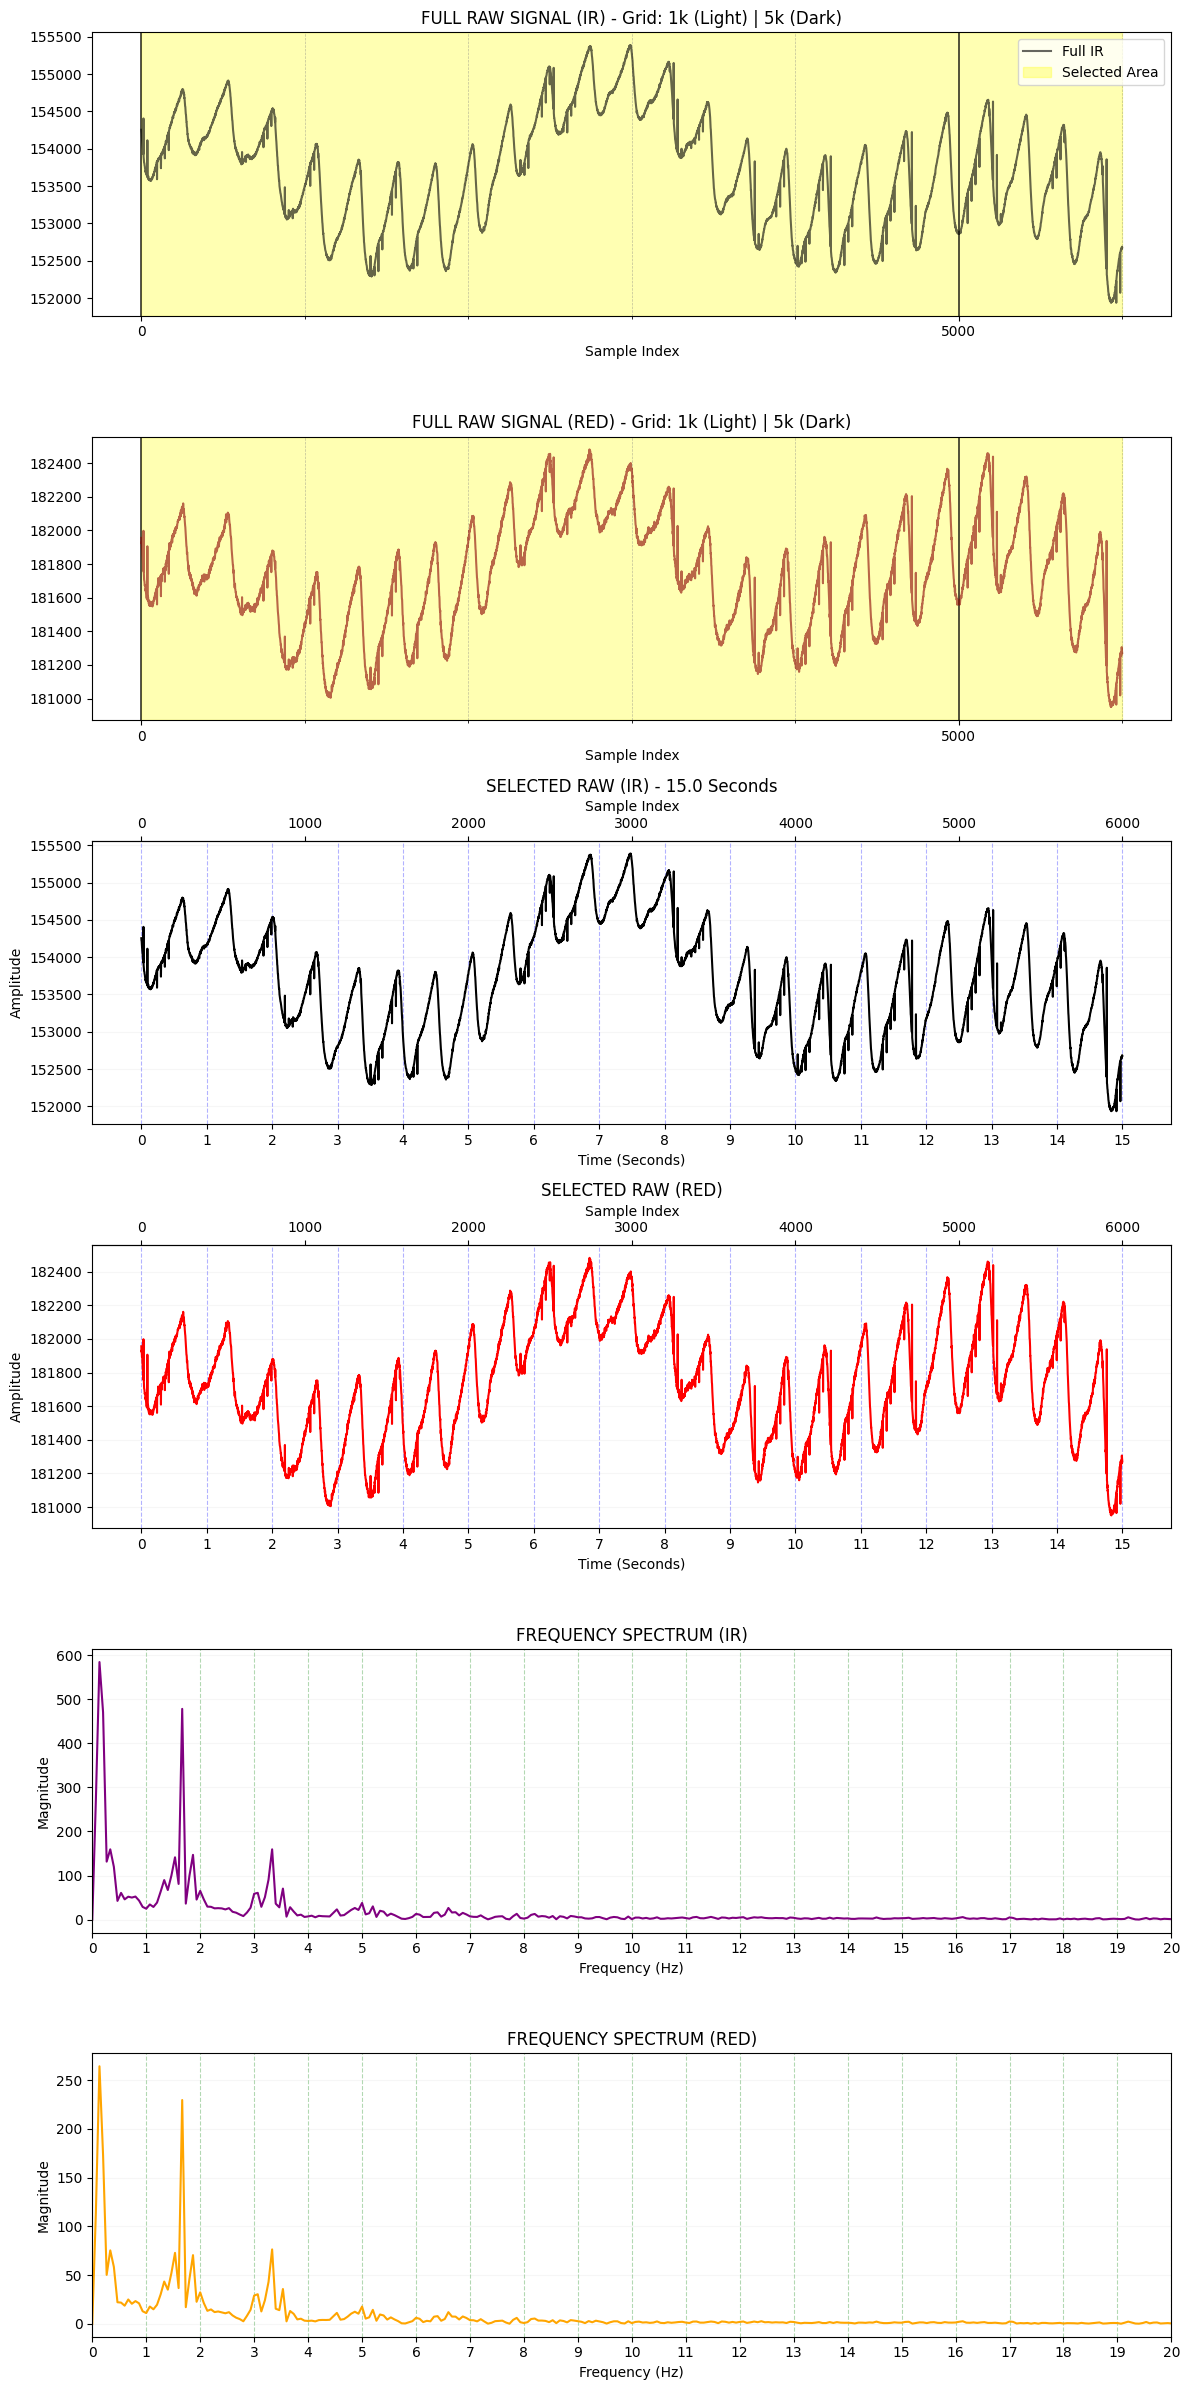

In [2]:
## Cell 320 — STEP 2: LOAD, SELECT, TIME & FREQ PLOTS

#```python
# ==========================================
# ⚙️ STEP 2: LOAD, SELECT, TIME & FREQ PLOTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.fft import fft, fftfreq

# 1. Load CSV
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()

rename_map = {
    'RED_VALUE': 'RED', 'IR_VALUE': 'IR',
    'RED VALUE': 'RED', 'IR VALUE': 'IR',
    'RED_RAW': 'RED',   'IR_RAW': 'IR'
}
df = df.rename(columns=rename_map)

required_cols = {'RED', 'IR'}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing required columns: {missing_cols}")

# 2. Apply Validity Thresholds
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
full_clean_df = df.loc[mask, ['RED', 'IR']].copy().reset_index(drop=True)

# 3. ✂️ APPLY SELECTION
if USE_FULL_FILE:
    selected_df = full_clean_df.copy()
    SAMPLE_START = 0
    SAMPLE_END = len(selected_df)
else:
    if SAMPLE_END == 0:
        SAMPLE_END = len(full_clean_df)
    s_end = min(SAMPLE_END, len(full_clean_df))
    selected_df = full_clean_df.iloc[SAMPLE_START:s_end].copy().reset_index(drop=True)

# --- FFT HELPER ---
def compute_fft(signal_data, fs):
    signal_data = np.asarray(signal_data)
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N // 2], 2.0 / N * np.abs(yf[:N // 2])

# --- SAFETY CHECK & PLOTTING ---
if len(selected_df) < 50:
    raise ValueError(f"❌ Selected range is too short ({len(selected_df)} samples).")

print(f"✅ Processing Range: {len(selected_df)} samples ({len(selected_df)/FS:.2f} seconds).")

time_axis = np.arange(len(selected_df)) / FS

total_fig_height = SUBPLOT_HEIGHT * 6
fig, axes = plt.subplots(6, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: FULL Data (IR) ---
axes[0].plot(full_clean_df['IR'].values, color='black', alpha=0.6, label='Full IR')
axes[0].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3, label='Selected Area')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(5000))
axes[0].xaxis.set_minor_locator(ticker.MultipleLocator(1000))
axes[0].grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1.2, alpha=0.8)
axes[0].grid(True, which='minor', axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0].set_xticks(np.arange(0, len(full_clean_df), 5000))
axes[0].set_title('FULL RAW SIGNAL (IR) - Grid: 1k (Light) | 5k (Dark)')
axes[0].set_xlabel('Sample Index')
axes[0].legend(loc='upper right')

# --- PLOT 2: FULL Data (RED) ---
axes[1].plot(full_clean_df['RED'].values, color='darkred', alpha=0.6, label='Full RED')
axes[1].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3)
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(5000))
axes[1].xaxis.set_minor_locator(ticker.MultipleLocator(1000))
axes[1].grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1.2, alpha=0.8)
axes[1].grid(True, which='minor', axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axes[1].set_xticks(np.arange(0, len(full_clean_df), 5000))
axes[1].set_title('FULL RAW SIGNAL (RED) - Grid: 1k (Light) | 5k (Dark)')
axes[1].set_xlabel('Sample Index')

# --- PLOT 3: SELECTED IR ---
axes[2].plot(time_axis, selected_df['IR'].values, color='black', linewidth=1.5)
axes[2].set_title(f'SELECTED RAW (IR) - {len(selected_df)/FS:.1f} Seconds')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (Seconds)')
sec_ax1 = axes[2].secondary_xaxis('top', functions=(lambda x: x * FS, lambda x: x / FS))
sec_ax1.set_xlabel('Sample Index')

# --- PLOT 4: SELECTED RED ---
axes[3].plot(time_axis, selected_df['RED'].values, color='red', linewidth=1.5)
axes[3].set_title('SELECTED RAW (RED)')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (Seconds)')
sec_ax2 = axes[3].secondary_xaxis('top', functions=(lambda x: x * FS, lambda x: x / FS))
sec_ax2.set_xlabel('Sample Index')

if TIME_VERTICAL_LINE_INTERVAL > 0:
    for ax in [axes[2], axes[3]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

# --- PLOT 5: FFT IR ---
xf_ir, yf_ir = compute_fft(selected_df['IR'].values, FS)
axes[4].plot(xf_ir, yf_ir, color='purple')
axes[4].set_title('FREQUENCY SPECTRUM (IR)')
axes[4].set_ylabel('Magnitude')
axes[4].set_xlabel('Frequency (Hz)')
axes[4].set_xlim(0, 20)

# --- PLOT 6: FFT RED ---
xf_red, yf_red = compute_fft(selected_df['RED'].values, FS)
axes[5].plot(xf_red, yf_red, color='orange')
axes[5].set_title('FREQUENCY SPECTRUM (RED)')
axes[5].set_ylabel('Magnitude')
axes[5].set_xlabel('Frequency (Hz)')
axes[5].set_xlim(0, 20)

if FREQ_VERTICAL_LINE_INTERVAL > 0:
    for ax in [axes[4], axes[5]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()
#```

#---

⚡ SPIKE REMOVAL: ENABLED (Kernel Size: 3)


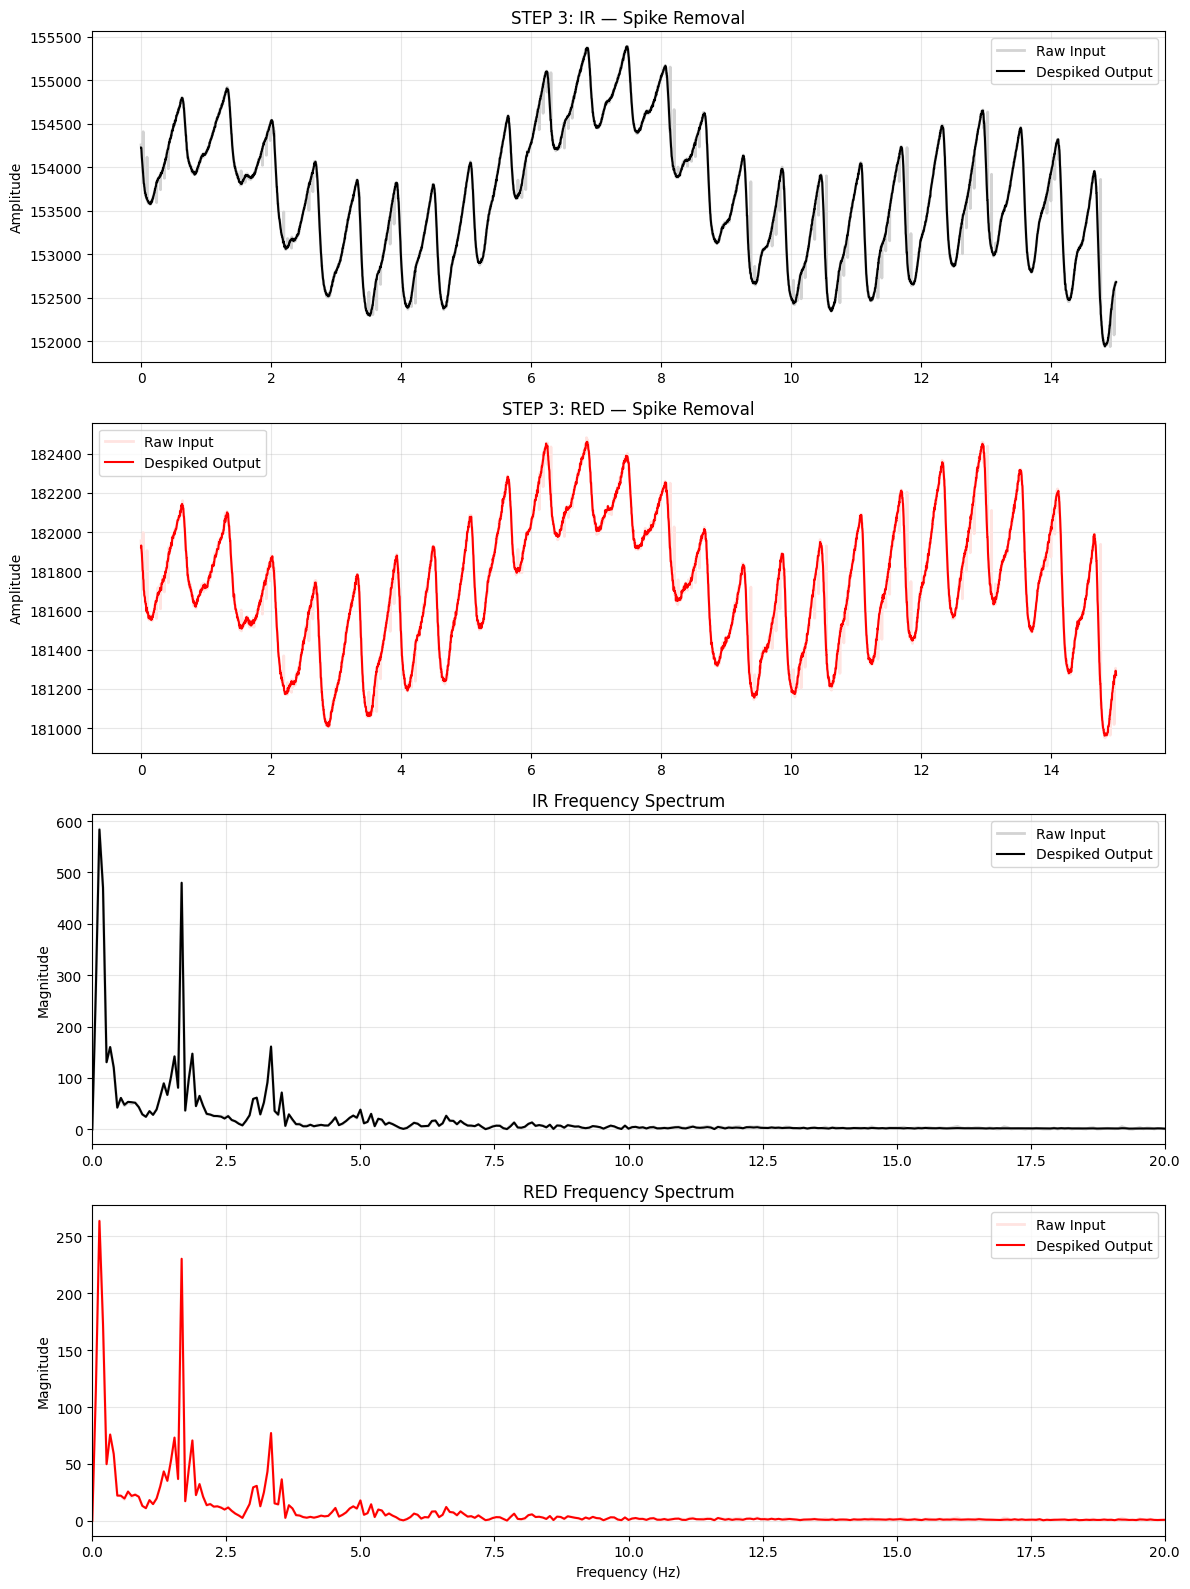

In [3]:
## Cell 321 — STEP 3: SPIKE REMOVAL (TIME + FREQ)

#```python
# ==========================================
# ⚙️ STEP 3: SPIKE REMOVAL (TIME + FREQ)
# ==========================================
import scipy.signal as signal
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np

if SPIKE_ENABLE:
    print(f"⚡ SPIKE REMOVAL: ENABLED (Kernel Size: {KERNEL_SIZE})")
    ir_despiked  = signal.medfilt(selected_df['IR'].values,  kernel_size=KERNEL_SIZE)
    red_despiked = signal.medfilt(selected_df['RED'].values, kernel_size=KERNEL_SIZE)
else:
    print("ℹ️ SPIKE REMOVAL: DISABLED (Skipping...)")
    ir_despiked  = selected_df['IR'].values.copy()
    red_despiked = selected_df['RED'].values.copy()

def compute_fft(signal_data, fs):
    signal_data = np.asarray(signal_data)
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N // 2], 2.0 / N * np.abs(yf[:N // 2])

time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4

fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- IR Time ---
axes[0].plot(time_axis, selected_df['IR'].values, color='lightgray', label='Raw Input', linewidth=2)
axes[0].plot(time_axis, ir_despiked, color='black', linewidth=1.5, label='Despiked Output')
axes[0].set_title('STEP 3: IR — Spike Removal')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

# --- RED Time ---
axes[1].plot(time_axis, selected_df['RED'].values, color='mistyrose', label='Raw Input', linewidth=2)
axes[1].plot(time_axis, red_despiked, color='red', linewidth=1.5, label='Despiked Output')
axes[1].set_title('STEP 3: RED — Spike Removal')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

# --- IR FFT ---
xf_ir_raw, yf_ir_raw = compute_fft(selected_df['IR'].values, FS)
xf_ir_des, yf_ir_des = compute_fft(ir_despiked, FS)
axes[2].plot(xf_ir_raw, yf_ir_raw, color='lightgray', linewidth=2, label='Raw Input')
axes[2].plot(xf_ir_des, yf_ir_des, color='black', linewidth=1.5, label='Despiked Output')
axes[2].set_xlim(0, 20)
axes[2].set_title('IR Frequency Spectrum')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

# --- RED FFT ---
xf_red_raw, yf_red_raw = compute_fft(selected_df['RED'].values, FS)
xf_red_des, yf_red_des = compute_fft(red_despiked, FS)
axes[3].plot(xf_red_raw, yf_red_raw, color='mistyrose', linewidth=2, label='Raw Input')
axes[3].plot(xf_red_des, yf_red_des, color='red', linewidth=1.5, label='Despiked Output')
axes[3].set_xlim(0, 20)
axes[3].set_title('RED Frequency Spectrum')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('Magnitude')
axes[3].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#```

#---



🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.


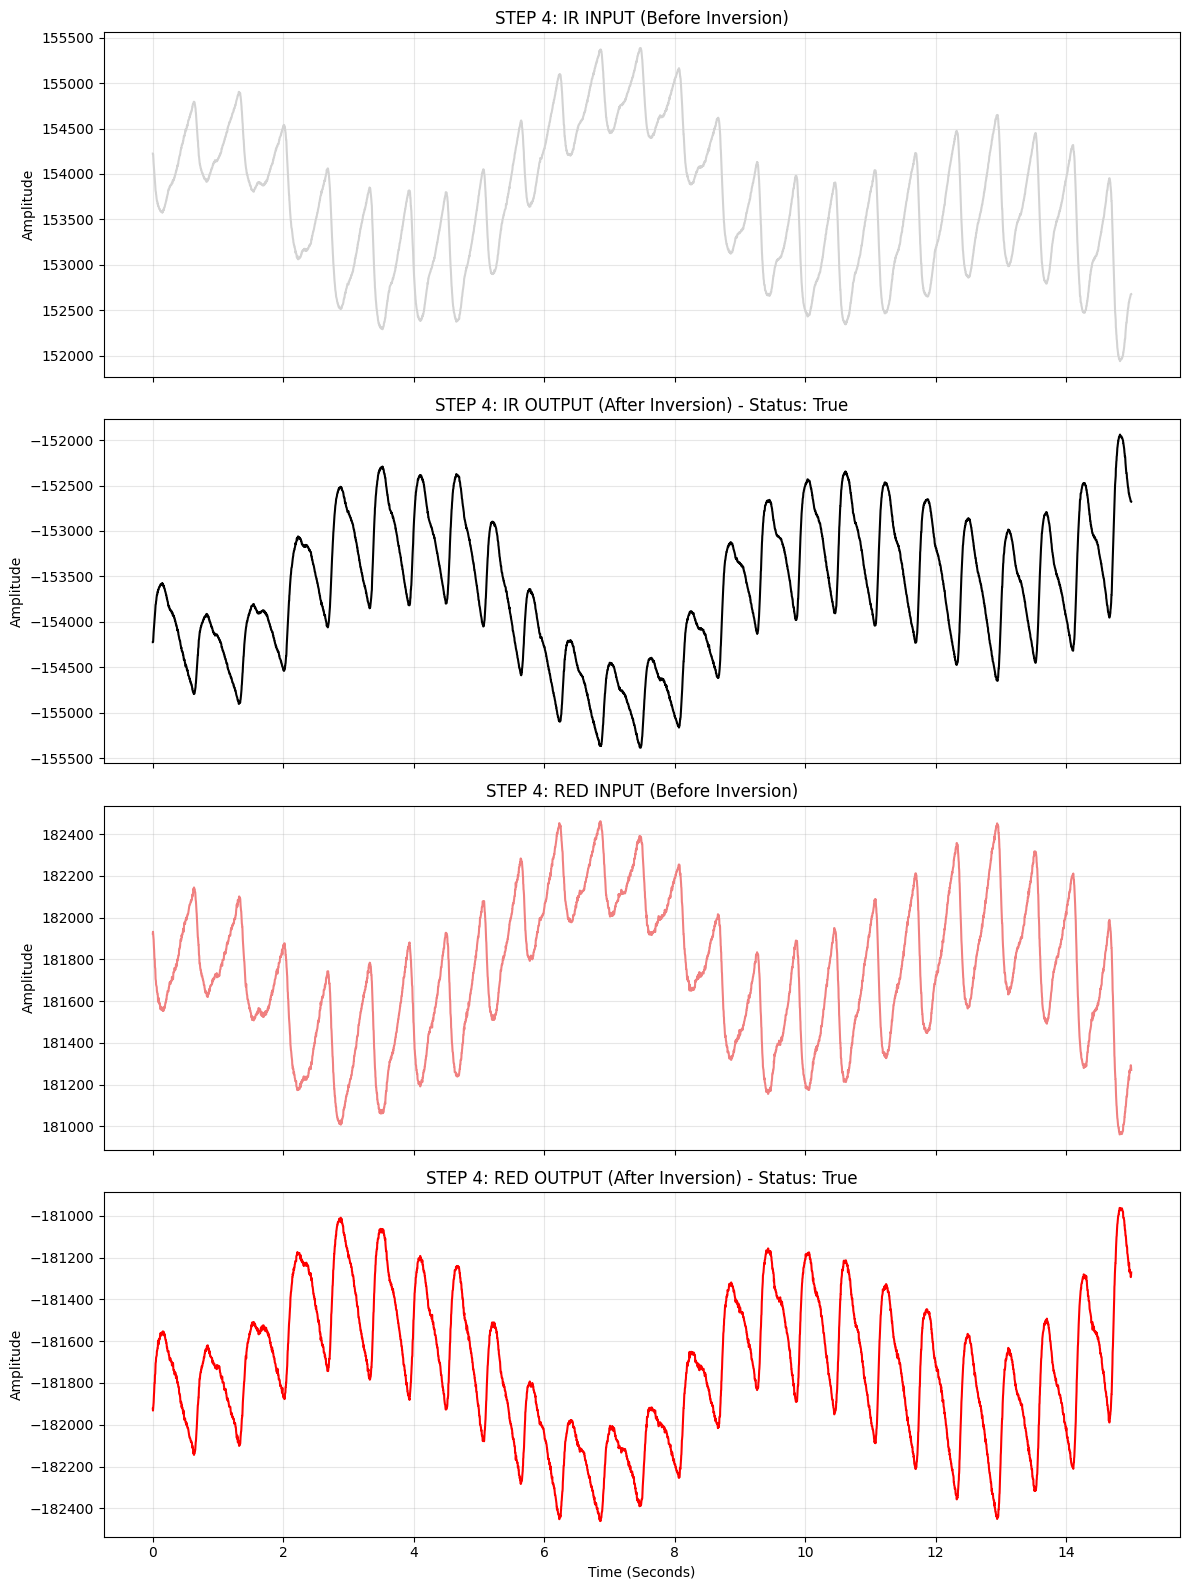

In [4]:
## Cell 322 — STEP 4: SIGNAL INVERSION

#```python
# ==========================================
# ⚙️ STEP 4: SIGNAL INVERSION
# ==========================================
# Fixes Morphology: MAX30102 raw values drop during a pulse.
# We multiply by -1 so the systolic peak points UP.

if INVERT_ENABLE:
    print("🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.")
    ir_inverted  = -1 * ir_despiked
    red_inverted = -1 * red_despiked
else:
    print("➡️ INVERSION SKIPPED: Passing signal through.")
    ir_inverted  = ir_despiked.copy()
    red_inverted = red_despiked.copy()

time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4

fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.6)

axes[0].plot(time_axis, ir_despiked, color='lightgray', linewidth=1.5)
axes[0].set_title('STEP 4: IR INPUT (Before Inversion)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(time_axis, ir_inverted, color='black', linewidth=1.5)
axes[1].set_title(f'STEP 4: IR OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[1].set_ylabel('Amplitude')

axes[2].plot(time_axis, red_despiked, color='lightcoral', linewidth=1.5)
axes[2].set_title('STEP 4: RED INPUT (Before Inversion)')
axes[2].set_ylabel('Amplitude')

axes[3].plot(time_axis, red_inverted, color='red', linewidth=1.5)
axes[3].set_title(f'STEP 4: RED OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (Seconds)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#```

#---

⚡ LOW-PASS FILTER: ENABLED (Cutoff: 16.0Hz, Order: 4)


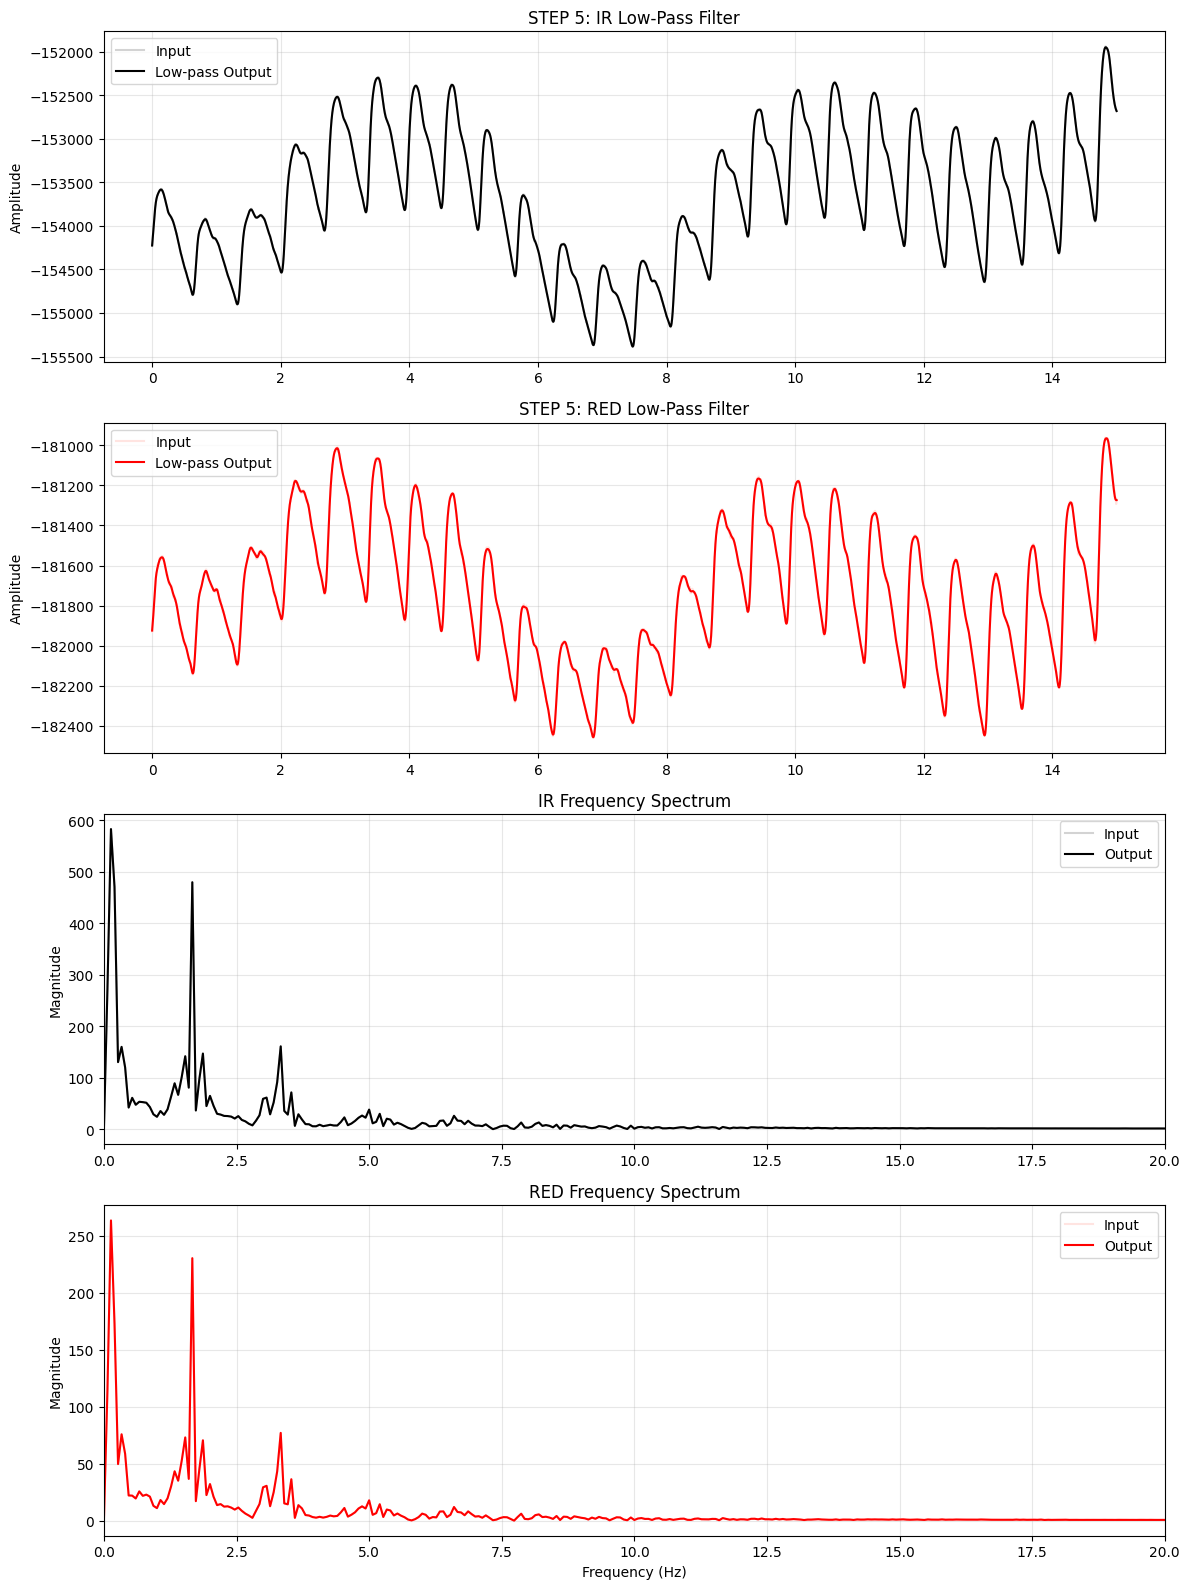

In [5]:
## Cell 323 — STEP 5: LOW-PASS FILTER

#```python
# ==========================================
# ⚙️ STEP 5: LOW-PASS FILTER (Noise Removal)
# ==========================================
# Removes high-frequency noise (muscle movement, electrical jitter).
# Crucial for revealing the dicrotic notch.

from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np

if LP_ENABLE:
    print(f"⚡ LOW-PASS FILTER: ENABLED (Cutoff: {LP_CUTOFF}Hz, Order: {LP_ORDER})")
    nyquist = 0.5 * FS
    sos = signal.butter(LP_ORDER, LP_CUTOFF / nyquist, btype='low', output='sos')
    ir_filtered  = signal.sosfiltfilt(sos, ir_inverted)
    red_filtered = signal.sosfiltfilt(sos, red_inverted)
else:
    print("⚠️ LOW-PASS FILTER: DISABLED (Skipping...)")
    ir_filtered  = ir_inverted.copy()
    red_filtered = red_inverted.copy()

# DC component is taken from low-pass output
dc_ir_val  = float(np.mean(ir_filtered))
dc_red_val = float(np.mean(red_filtered))

def compute_fft(signal_data, fs):
    signal_data = np.asarray(signal_data)
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N // 2], 2.0 / N * np.abs(yf[:N // 2])

time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# Time domain
axes[0].plot(time_axis, ir_inverted, color='lightgray', label='Input', linewidth=1.5)
axes[0].plot(time_axis, ir_filtered, color='black', label='Low-pass Output', linewidth=1.5)
axes[0].set_title('STEP 5: IR Low-Pass Filter')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(time_axis, red_inverted, color='mistyrose', label='Input', linewidth=1.5)
axes[1].plot(time_axis, red_filtered, color='red', label='Low-pass Output', linewidth=1.5)
axes[1].set_title('STEP 5: RED Low-Pass Filter')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

# Frequency domain
xf_ir_in, yf_ir_in = compute_fft(ir_inverted, FS)
xf_ir_out, yf_ir_out = compute_fft(ir_filtered, FS)
axes[2].plot(xf_ir_in, yf_ir_in, color='lightgray', label='Input', linewidth=1.5)
axes[2].plot(xf_ir_out, yf_ir_out, color='black', label='Output', linewidth=1.5)
axes[2].set_xlim(0, 20)
axes[2].set_title('IR Frequency Spectrum')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

xf_red_in, yf_red_in = compute_fft(red_inverted, FS)
xf_red_out, yf_red_out = compute_fft(red_filtered, FS)
axes[3].plot(xf_red_in, yf_red_in, color='mistyrose', label='Input', linewidth=1.5)
axes[3].plot(xf_red_out, yf_red_out, color='red', label='Output', linewidth=1.5)
axes[3].set_xlim(0, 20)
axes[3].set_title('RED Frequency Spectrum')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('Magnitude')
axes[3].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#```

#---

ℹ️ SG SMOOTHING: DISABLED (Skipping...)


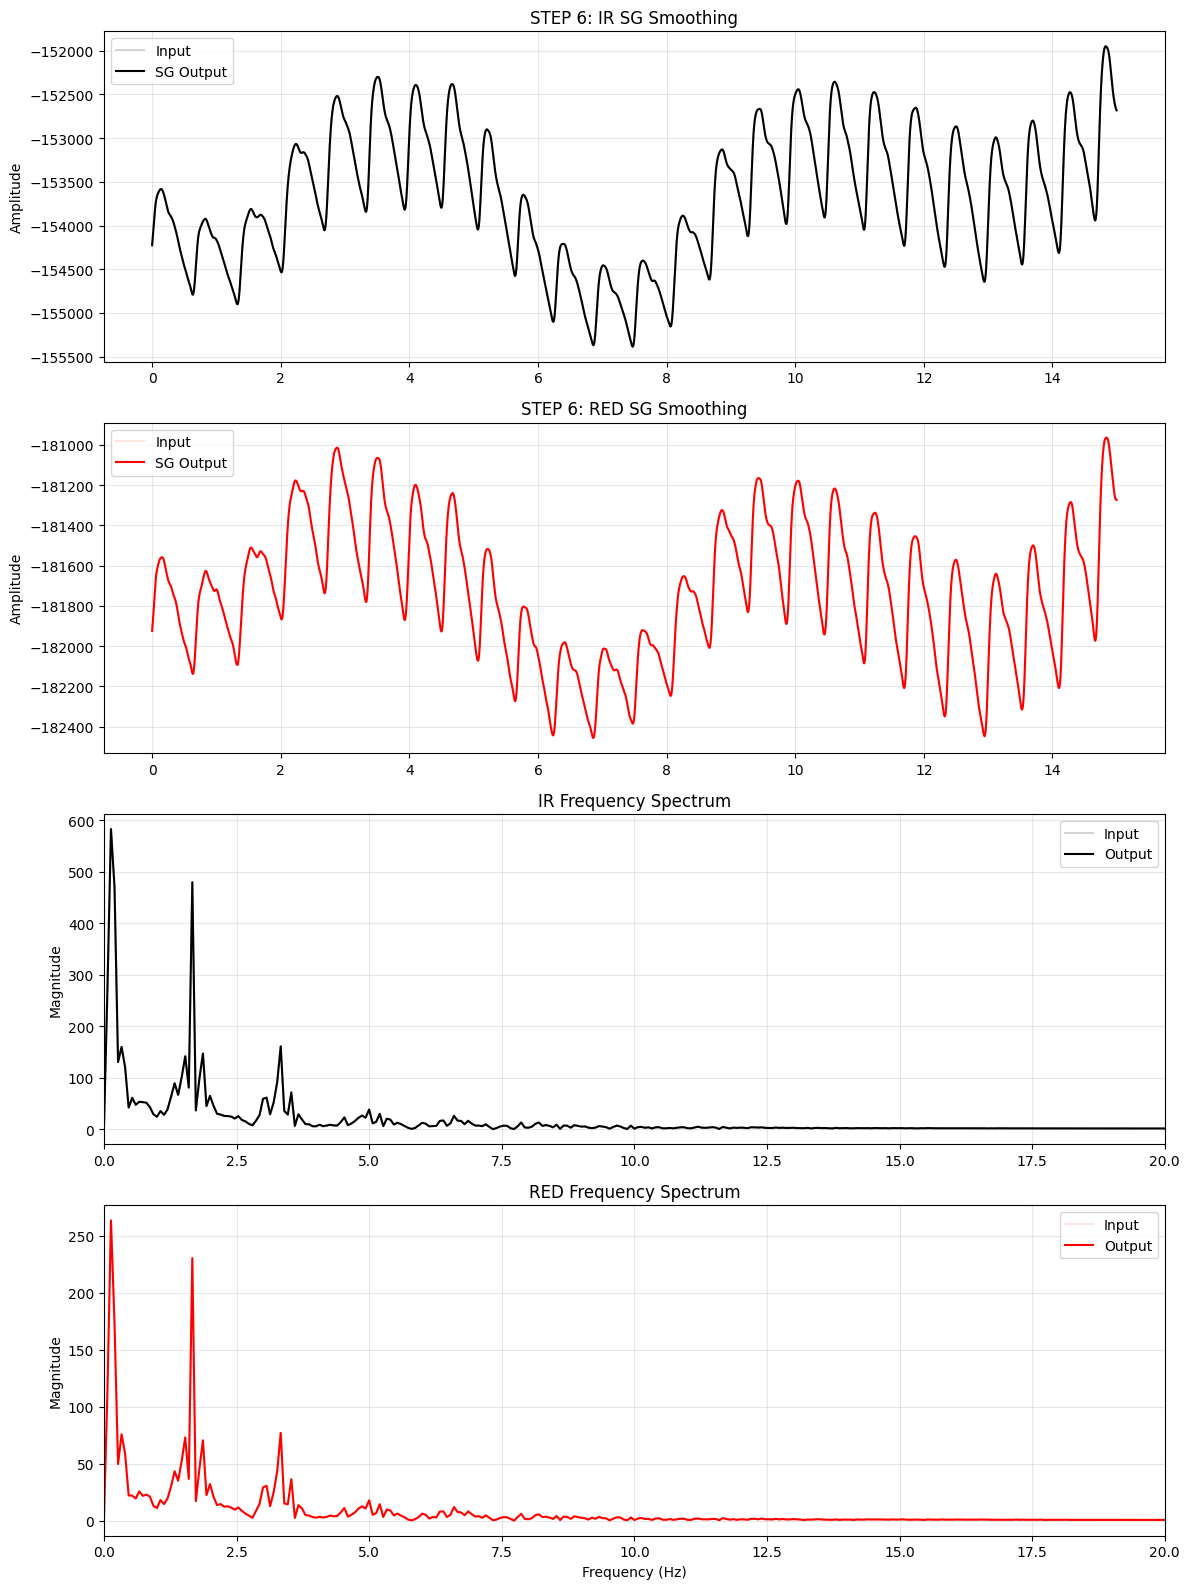

In [6]:
## Cell 324 — STEP 6: SAVITZKY-GOLAY SMOOTHING

#```python
# ==========================================
# ⚙️ STEP 6: SAVITZKY-GOLAY SMOOTHING
# ==========================================

from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np

safe_window = int(SG_WINDOW)
safe_poly   = int(SG_POLY)

if safe_window % 2 == 0:
    safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be ODD)")

if safe_window <= safe_poly:
    safe_window = safe_poly + 2
    if safe_window % 2 == 0:
        safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be > Poly Order)")

if SG_ENABLE:
    print(f"✨ SG SMOOTHING: ENABLED (Window: {safe_window}, Poly: {safe_poly})")
    ir_smoothed  = signal.savgol_filter(ir_filtered,  window_length=safe_window, polyorder=safe_poly)
    red_smoothed = signal.savgol_filter(red_filtered, window_length=safe_window, polyorder=safe_poly)
else:
    print("ℹ️ SG SMOOTHING: DISABLED (Skipping...)")
    ir_smoothed  = ir_filtered.copy()
    red_smoothed = red_filtered.copy()

def compute_fft(signal_data, fs):
    signal_data = np.asarray(signal_data)
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N // 2], 2.0 / N * np.abs(yf[:N // 2])

time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

axes[0].plot(time_axis, ir_filtered, color='lightgray', label='Input', linewidth=1.5)
axes[0].plot(time_axis, ir_smoothed, color='black', label='SG Output', linewidth=1.5)
axes[0].set_title('STEP 6: IR SG Smoothing')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(time_axis, red_filtered, color='mistyrose', label='Input', linewidth=1.5)
axes[1].plot(time_axis, red_smoothed, color='red', label='SG Output', linewidth=1.5)
axes[1].set_title('STEP 6: RED SG Smoothing')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

xf_ir_in, yf_ir_in = compute_fft(ir_filtered, FS)
xf_ir_out, yf_ir_out = compute_fft(ir_smoothed, FS)
axes[2].plot(xf_ir_in, yf_ir_in, color='lightgray', label='Input', linewidth=1.5)
axes[2].plot(xf_ir_out, yf_ir_out, color='black', label='Output', linewidth=1.5)
axes[2].set_xlim(0, 20)
axes[2].set_title('IR Frequency Spectrum')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

xf_red_in, yf_red_in = compute_fft(red_filtered, FS)
xf_red_out, yf_red_out = compute_fft(red_smoothed, FS)
axes[3].plot(xf_red_in, yf_red_in, color='mistyrose', label='Input', linewidth=1.5)
axes[3].plot(xf_red_out, yf_red_out, color='red', label='Output', linewidth=1.5)
axes[3].set_xlim(0, 20)
axes[3].set_title('RED Frequency Spectrum')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('Magnitude')
axes[3].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#```

#---


📈 Plotting Frequency Spectrum After Savitzky–Golay Smoothing...


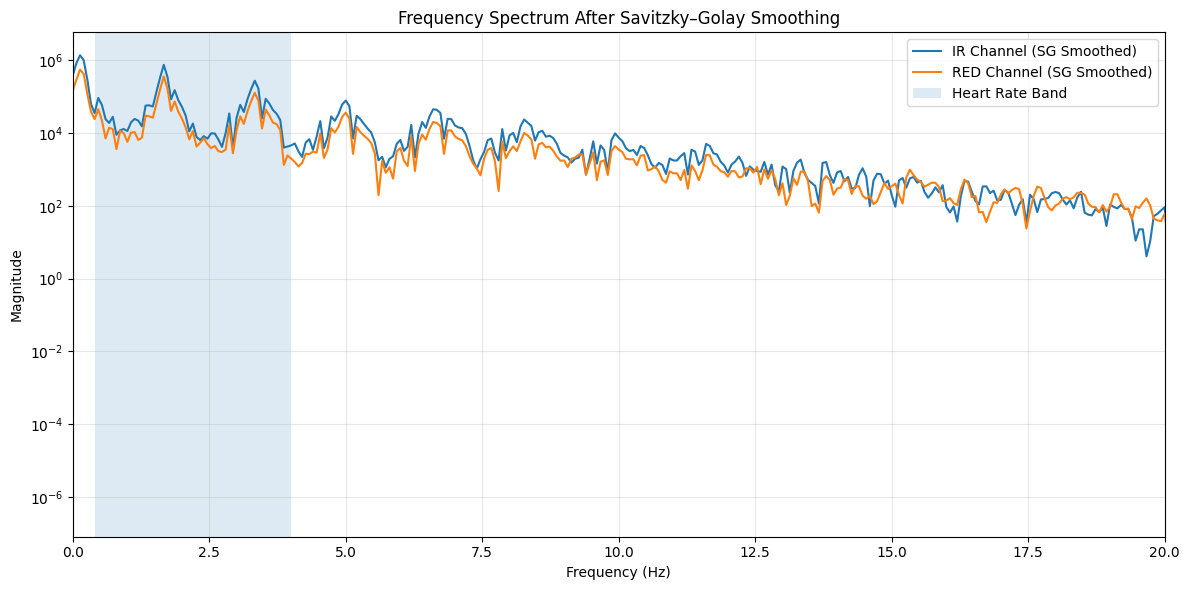

In [7]:
# ==========================================
# 📈 FREQUENCY SPECTRUM AFTER SAVITZKY–GOLAY
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

print("\n📈 Plotting Frequency Spectrum After Savitzky–Golay Smoothing...")

# -------------------------------------------------
# 1. Use SG-smoothed signals from your pipeline
# -------------------------------------------------
sig_red = np.asarray(red_smoothed, dtype=float)
sig_ir  = np.asarray(ir_smoothed, dtype=float)

# -------------------------------------------------
# 2. Remove mean (remove DC component)
# -------------------------------------------------
sig_red = sig_red - np.mean(sig_red)
sig_ir  = sig_ir  - np.mean(sig_ir)

# -------------------------------------------------
# 3. Apply Hann window (reduce leakage)
# -------------------------------------------------
N = len(sig_red)
window = np.hanning(N)

sig_red_win = sig_red * window
sig_ir_win  = sig_ir * window

# -------------------------------------------------
# 4. FFT
# -------------------------------------------------
freqs = np.fft.rfftfreq(N, d=1/FS)

fft_red = np.fft.rfft(sig_red_win)
fft_ir  = np.fft.rfft(sig_ir_win)

# magnitude spectrum (always positive)
mag_red = np.abs(fft_red)
mag_ir  = np.abs(fft_ir)

# avoid log(0)
eps = 1e-12
mag_red = np.maximum(mag_red, eps)
mag_ir  = np.maximum(mag_ir, eps)

# -------------------------------------------------
# 5. Plot
# -------------------------------------------------
plt.figure(figsize=(12,6))

plt.semilogy(freqs, mag_ir, label='IR Channel (SG Smoothed)')
plt.semilogy(freqs, mag_red, label='RED Channel (SG Smoothed)')

# heart rate band
plt.axvspan(0.4, 4.0, alpha=0.15, label='Heart Rate Band')

plt.title("Frequency Spectrum After Savitzky–Golay Smoothing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0,20)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
print("Available variables:")
print("red_filtered:", 'red_filtered' in globals())
print("ir_filtered :", 'ir_filtered' in globals())
print("red_norm    :", 'red_norm' in globals())
print("ir_norm     :", 'ir_norm' in globals())

Available variables:
red_filtered: True
ir_filtered : True
red_norm    : False
ir_norm     : False



⚙️ STEP 7: HIGH-PASS FILTER VISUALIZATION


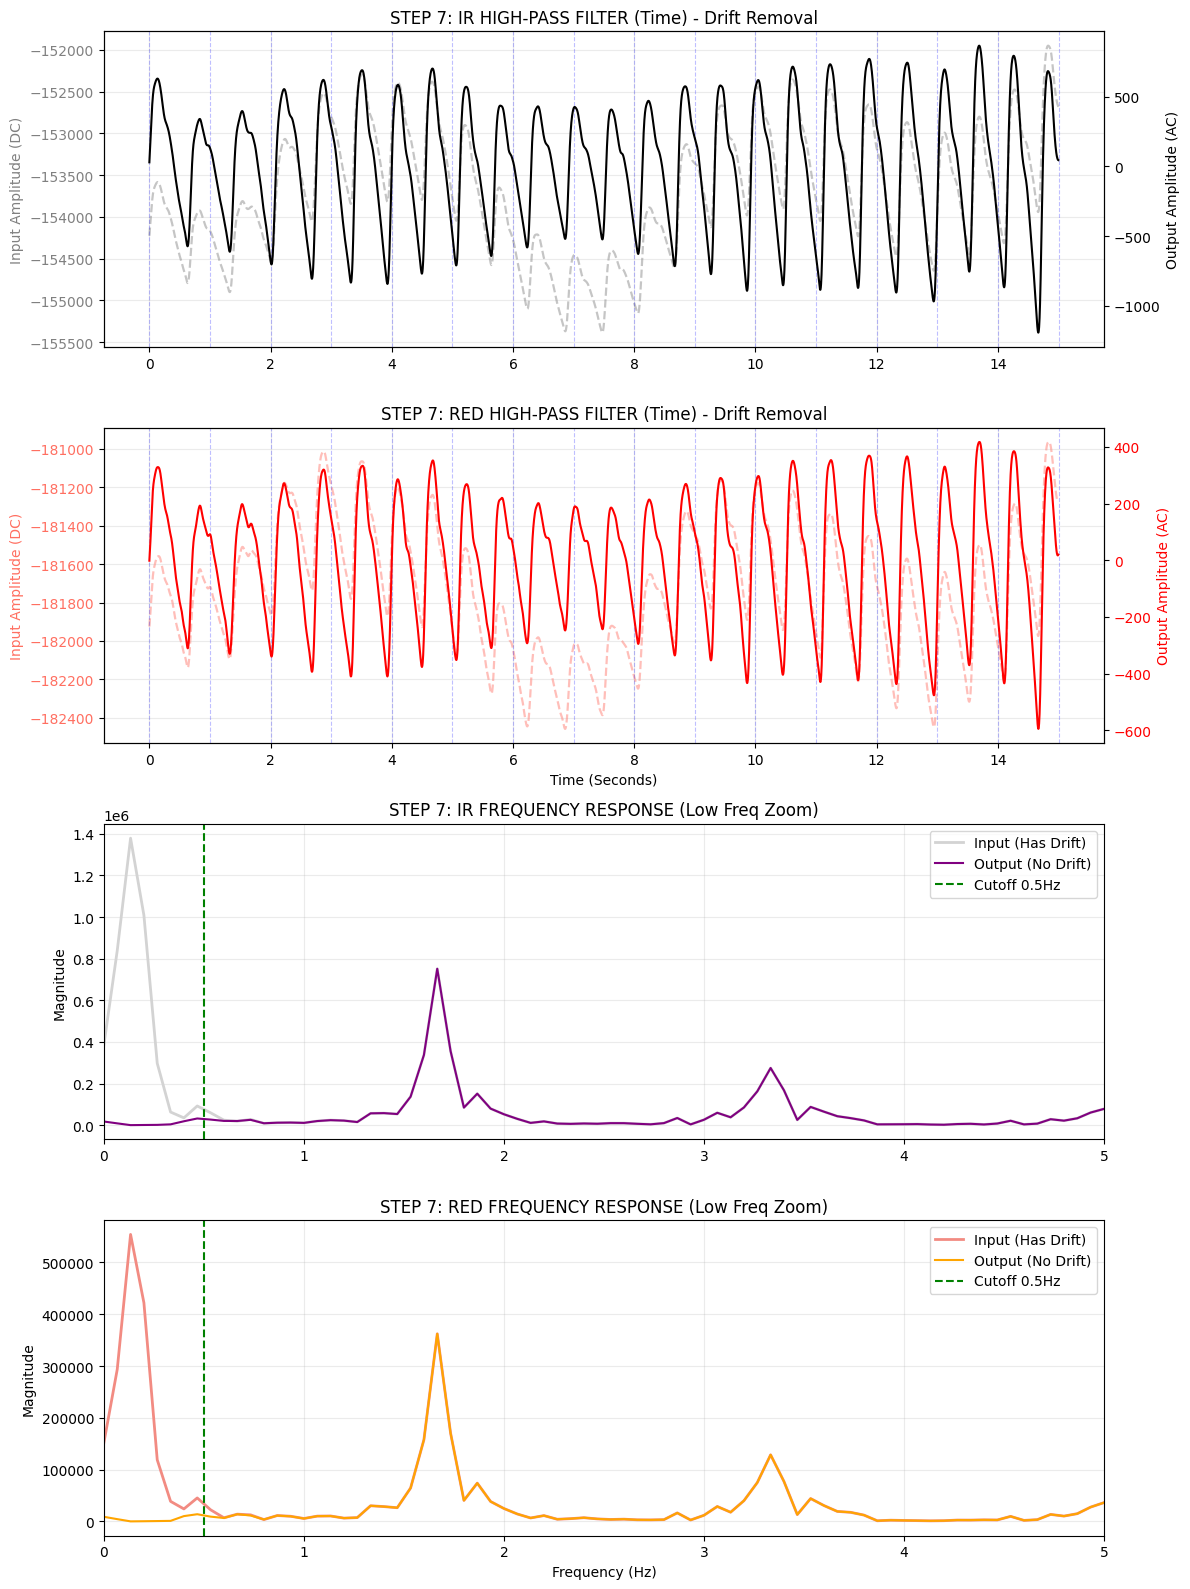


✅ High-pass filter visualization completed.
   Cutoff Frequency: 0.5 Hz
   Filter Order: 4


In [9]:
# ==========================================
# ⚙️ STEP 7: HIGH-PASS FILTER VISUALIZATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

print("\n" + "="*50)
print("⚙️ STEP 7: HIGH-PASS FILTER VISUALIZATION")
print("="*50)

# -------------------------------------------------
# 1. SETTINGS
# -------------------------------------------------
HP_CUTOFF = 0.5     # Hz
HP_ORDER  = 4
LOW_FREQ_ZOOM_MAX = 5.0  # Hz for FFT zoom

# -------------------------------------------------
# 2. BUTTERWORTH HIGH-PASS FILTER
# -------------------------------------------------
def butter_highpass_filter(signal_data, cutoff_hz, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered = filtfilt(b, a, signal_data)
    return filtered

# -------------------------------------------------
# 3. FFT HELPER
# -------------------------------------------------
def compute_fft_magnitude(signal_data, fs):
    x = np.asarray(signal_data, dtype=float)
    x = x - np.mean(x)   # remove DC for better spectrum view

    N = len(x)
    window = np.hanning(N)
    xw = x * window

    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    fft_vals = np.fft.rfft(xw)
    mag = np.abs(fft_vals)

    return freqs, mag

# -------------------------------------------------
# 4. INPUT SIGNALS
# -------------------------------------------------
# Use the signal stage before HP filter.
# If your notebook already has these exact variables, this works directly.
sig_ir_in  = np.asarray(ir_filtered, dtype=float)
sig_red_in = np.asarray(red_filtered, dtype=float)

# -------------------------------------------------
# 5. APPLY HIGH-PASS FILTER
# -------------------------------------------------
ir_hpf_plot  = butter_highpass_filter(sig_ir_in,  HP_CUTOFF, FS, order=HP_ORDER)
red_hpf_plot = butter_highpass_filter(sig_red_in, HP_CUTOFF, FS, order=HP_ORDER)

# Optional: keep these as your pipeline variables too
ir_hpf  = ir_hpf_plot.copy()
red_hpf = red_hpf_plot.copy()

# -------------------------------------------------
# 6. TIME AXIS
# -------------------------------------------------
t = np.arange(len(sig_ir_in)) / FS

# -------------------------------------------------
# 7. FFTs
# -------------------------------------------------
freq_ir_in,  mag_ir_in  = compute_fft_magnitude(sig_ir_in, FS)
freq_ir_out, mag_ir_out = compute_fft_magnitude(ir_hpf_plot, FS)

freq_red_in,  mag_red_in  = compute_fft_magnitude(sig_red_in, FS)
freq_red_out, mag_red_out = compute_fft_magnitude(red_hpf_plot, FS)

# -------------------------------------------------
# 8. PLOT
# -------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# =================================================
# ROW 1: IR TIME DOMAIN
# =================================================
ax1 = axes[0]

ax1.plot(t, sig_ir_in, color='gray', linestyle='--', alpha=0.45, linewidth=1.6)
ax1.set_ylabel("Input Amplitude (DC)", color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax1.set_title("STEP 7: IR HIGH-PASS FILTER (Time) - Drift Removal")
ax1.grid(True, alpha=0.25)

# vertical second markers
for sec in range(int(np.floor(t[0])), int(np.ceil(t[-1])) + 1):
    ax1.axvline(sec, color='blue', linestyle='--', alpha=0.25, linewidth=0.8)

ax1b = ax1.twinx()
ax1b.plot(t, ir_hpf_plot, color='black', linewidth=1.5)
ax1b.set_ylabel("Output Amplitude (AC)", color='black')
ax1b.tick_params(axis='y', labelcolor='black')

# =================================================
# ROW 2: RED TIME DOMAIN
# =================================================
ax2 = axes[1]

ax2.plot(t, sig_red_in, color='#ff8a80', linestyle='--', alpha=0.55, linewidth=1.6)
ax2.set_ylabel("Input Amplitude (DC)", color='#ff6f61')
ax2.tick_params(axis='y', labelcolor='#ff6f61')
ax2.set_title("STEP 7: RED HIGH-PASS FILTER (Time) - Drift Removal")
ax2.grid(True, alpha=0.25)

for sec in range(int(np.floor(t[0])), int(np.ceil(t[-1])) + 1):
    ax2.axvline(sec, color='blue', linestyle='--', alpha=0.25, linewidth=0.8)

ax2b = ax2.twinx()
ax2b.plot(t, red_hpf_plot, color='red', linewidth=1.5)
ax2b.set_ylabel("Output Amplitude (AC)", color='red')
ax2b.tick_params(axis='y', labelcolor='red')

ax2.set_xlabel("Time (Seconds)")

# =================================================
# ROW 3: IR FREQUENCY RESPONSE
# =================================================
ax3 = axes[2]

mask_ir = freq_ir_in <= LOW_FREQ_ZOOM_MAX
ax3.plot(freq_ir_in[mask_ir],  mag_ir_in[mask_ir],  color='lightgray', linewidth=2, label='Input (Has Drift)')
ax3.plot(freq_ir_out[mask_ir], mag_ir_out[mask_ir], color='purple', linewidth=1.5, label='Output (No Drift)')
ax3.axvline(HP_CUTOFF, color='green', linestyle='--', linewidth=1.5, label=f'Cutoff {HP_CUTOFF}Hz')

ax3.set_title("STEP 7: IR FREQUENCY RESPONSE (Low Freq Zoom)")
ax3.set_ylabel("Magnitude")
ax3.set_xlim(0, LOW_FREQ_ZOOM_MAX)
ax3.grid(True, alpha=0.25)
ax3.legend(loc='upper right')

# =================================================
# ROW 4: RED FREQUENCY RESPONSE
# =================================================
ax4 = axes[3]

mask_red = freq_red_in <= LOW_FREQ_ZOOM_MAX
ax4.plot(freq_red_in[mask_red],  mag_red_in[mask_red],  color='#f28b82', linewidth=2, label='Input (Has Drift)')
ax4.plot(freq_red_out[mask_red], mag_red_out[mask_red], color='orange', linewidth=1.5, label='Output (No Drift)')
ax4.axvline(HP_CUTOFF, color='green', linestyle='--', linewidth=1.5, label=f'Cutoff {HP_CUTOFF}Hz')

ax4.set_title("STEP 7: RED FREQUENCY RESPONSE (Low Freq Zoom)")
ax4.set_xlabel("Frequency (Hz)")
ax4.set_ylabel("Magnitude")
ax4.set_xlim(0, LOW_FREQ_ZOOM_MAX)
ax4.grid(True, alpha=0.25)
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ High-pass filter visualization completed.")
print(f"   Cutoff Frequency: {HP_CUTOFF} Hz")
print(f"   Filter Order: {HP_ORDER}")

⚡ NORMALIZATION APPLIED: Min-Max (0-1)


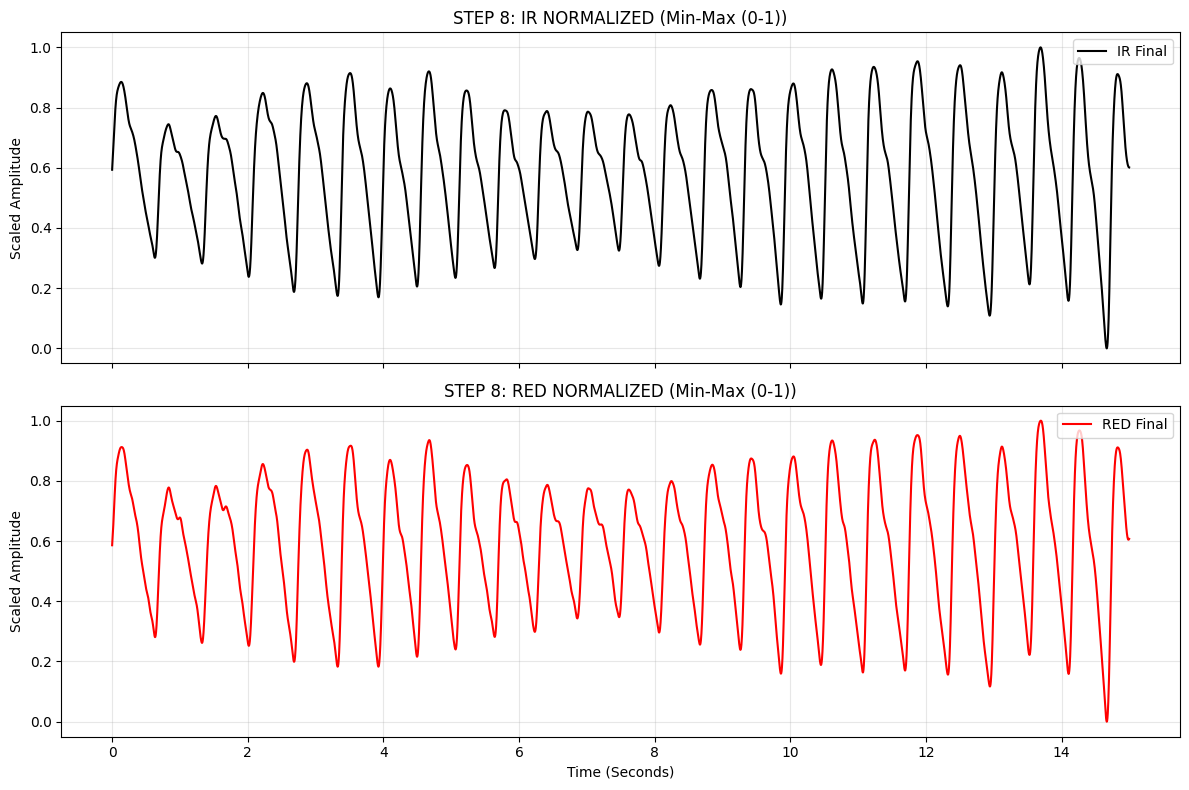

In [10]:
## Cell 327 — STEP 8: NORMALIZATION

#```python
# ==========================================
# ⚙️ STEP 8: NORMALIZATION
# ==========================================

ir_norm  = apply_normalization(ir_hpf,  selection=NORM_SELECTION)
red_norm = apply_normalization(red_hpf, selection=NORM_SELECTION)

norm_type = "Min-Max (0-1)" if NORM_SELECTION == 1 else "Z-Score (Std=1)"
print(f"⚡ NORMALIZATION APPLIED: {norm_type}")

time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 2

fig, axes = plt.subplots(2, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.4)

axes[0].plot(time_axis, ir_norm, color='black', linewidth=1.5, label='IR Final')
axes[0].set_title(f'STEP 8: IR NORMALIZED ({norm_type})')
axes[0].set_ylabel('Scaled Amplitude')
axes[0].legend(loc='upper right')

axes[1].plot(time_axis, red_norm, color='red', linewidth=1.5, label='RED Final')
axes[1].set_title(f'STEP 8: RED NORMALIZED ({norm_type})')
axes[1].set_ylabel('Scaled Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#```

#---

In [11]:
## Cell 328 — STEP 9: ADVANCED SIGNAL QUALITY CHECK

#```python
# ==========================================
# ⚙️ STEP 9: ADVANCED SIGNAL QUALITY CHECK
# ==========================================

def calculate_snr(signal_data, fs):
    """
    Calculates Spectral Signal-to-Noise Ratio (SNR).
    Signal Power: 0.5 Hz to 5.0 Hz
    Noise Power: everything else up to Nyquist
    """
    freqs, psd = signal.periodogram(signal_data, fs)
    sig_mask = (freqs >= 0.5) & (freqs <= 5.0)
    noise_mask = ~sig_mask

    sig_power = np.sum(psd[sig_mask])
    noise_power = np.sum(psd[noise_mask])

    if noise_power == 0:
        return 100.0

    return 10 * np.log10(sig_power / noise_power)

def calculate_zcr(signal_data):
    centered = signal_data - np.mean(signal_data)
    crossings = np.diff(np.signbit(centered)).sum()
    return crossings / len(signal_data)

def check_quality_advanced(name, clean_sig, raw_sig_for_dc, fs):
    print(f"\n📋 HIGH-STANDARD QUALITY REPORT: {name}")
    print("=" * 95)

    skew = stats.skew(clean_sig)
    skew_status = "✅ PASS" if SQI_LIMITS['SKEWNESS_MIN'] <= skew <= SQI_LIMITS['SKEWNESS_MAX'] else "⚠️"

    kurt = stats.kurtosis(clean_sig)
    kurt_status = "✅ PASS" if SQI_LIMITS['KURTOSIS_MIN'] <= kurt <= SQI_LIMITS['KURTOSIS_MAX'] else "⚠️"

    dc_val = np.mean(raw_sig_for_dc)
    ac_amp = np.max(clean_sig) - np.min(clean_sig)
    pi = (ac_amp / dc_val) * 100 if dc_val != 0 else 0
    pi_status = "✅ PASS" if SQI_LIMITS['PI_MIN'] <= pi <= SQI_LIMITS['PI_MAX'] else "⚠️"

    zcr = calculate_zcr(clean_sig) * fs
    zcr_status = "✅ PASS" if SQI_LIMITS['ZCR_MIN'] <= zcr <= SQI_LIMITS['ZCR_MAX'] else "⚠️"

    snr = calculate_snr(clean_sig, fs)
    snr_status = "✅ PASS" if SQI_LIMITS['SNR_MIN_DB'] <= snr <= SQI_LIMITS['SNR_MAX_DB'] else "⚠️"

    print(f"Skewness              : {skew:8.4f}   {skew_status}")
    print(f"Kurtosis              : {kurt:8.4f}   {kurt_status}")
    print(f"Perfusion Index (PI)  : {pi:8.4f}%  {pi_status}")
    print(f"Zero Crossing Rate    : {zcr:8.4f} Hz  {zcr_status}")
    print(f"SNR                   : {snr:8.4f} dB  {snr_status}")

    return {
        "skew": skew,
        "kurt": kurt,
        "pi": pi,
        "zcr": zcr,
        "snr": snr
    }

quality_ir = check_quality_advanced("IR Channel", ir_hpf, selected_df['IR'].values, FS)
quality_red = check_quality_advanced("RED Channel", red_hpf, selected_df['RED'].values, FS)
#```

#---


📋 HIGH-STANDARD QUALITY REPORT: IR Channel
Skewness              :  -0.2662   ⚠️
Kurtosis              :  -0.9015   ⚠️
Perfusion Index (PI)  :   1.3399%  ✅ PASS
Zero Crossing Rate    :   3.2000 Hz  ✅ PASS
SNR                   :  17.2010 dB  ✅ PASS

📋 HIGH-STANDARD QUALITY REPORT: RED Channel
Skewness              :  -0.2801   ⚠️
Kurtosis              :  -0.8835   ⚠️
Perfusion Index (PI)  :   0.5573%  ✅ PASS
Zero Crossing Rate    :   3.2667 Hz  ✅ PASS
SNR                   :  17.2746 dB  ✅ PASS


In [12]:
## Cell 329 — STEP 10: FULL PIPELINE DIAGNOSTIC REPORT

#```python
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.signal import welch

# ==========================================
# ⚙️ STEP 10: FULL PIPELINE DIAGNOSTIC REPORT
# ==========================================

def calculate_sqi_metrics(sig_ac, sig_raw_for_dc, fs):
    """
    Calculates SQI metrics for a given signal stage.
    """
    skew = stats.skew(sig_ac)
    kurt = stats.kurtosis(sig_ac)

    centered = sig_ac - np.mean(sig_ac)
    zcr_count = ((centered[:-1] * centered[1:]) < 0).sum()
    zcr = zcr_count / (len(sig_ac) / fs)

    f, Pxx = welch(sig_ac, fs=fs, nperseg=min(len(sig_ac), 1024))
    band_mask = (f >= 0.5) & (f <= 4.0)
    signal_power = np.sum(Pxx[band_mask])
    noise_power = np.sum(Pxx) - signal_power
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else 0

    ac_amp = np.max(sig_ac) - np.min(sig_ac)
    dc_val = np.mean(sig_raw_for_dc)
    pi = (ac_amp / dc_val) * 100 if dc_val != 0 else 0

    return skew, kurt, snr, zcr, pi

pipeline_stages = [
    ("1. Raw", selected_df['IR'].values, selected_df['RED'].values, selected_df['IR'].values, selected_df['RED'].values),
    ("2. Despiked", ir_despiked, red_despiked, selected_df['IR'].values, selected_df['RED'].values),
    ("3. Inverted", ir_inverted, red_inverted, selected_df['IR'].values, selected_df['RED'].values),
    ("4. Low-Pass", ir_filtered, red_filtered, selected_df['IR'].values, selected_df['RED'].values),
    ("5. SG Smoothed", ir_smoothed, red_smoothed, selected_df['IR'].values, selected_df['RED'].values),
    ("6. High-Pass", ir_hpf, red_hpf, selected_df['IR'].values, selected_df['RED'].values),
]

print("\n" + "-" * 100)
print("📋 FULL PIPELINE DIAGNOSTIC REPORT")
print("-" * 100)
print(f"{'Stage':<20} | {'CH':<3} | {'Skew':>7} | {'Kurt':>7} | {'SNR':>7} | {'ZCR':>10} | {'PI':>7} | {'R':>7} | {'Status'}")
print("-" * 100)

for stage_name, ir_sig, red_sig, ir_dc_src, red_dc_src in pipeline_stages:
    ir_skew, ir_kurt, ir_snr, ir_zcr, ir_pi = calculate_sqi_metrics(ir_sig, ir_dc_src, FS)
    red_skew, red_kurt, red_snr, red_zcr, red_pi = calculate_sqi_metrics(red_sig, red_dc_src, FS)

    if np.mean(red_dc_src) != 0 and np.mean(ir_dc_src) != 0 and ir_pi != 0:
        r_val = (red_pi / ir_pi)
    else:
        r_val = np.nan

    ir_status = "✅" if ir_snr >= 5 else "⚠️"
    red_status = "✅" if red_snr >= 5 else "⚠️"

    print(f"{stage_name:<20} | {'IR':<3} | {ir_skew:7.2f} | {ir_kurt:7.2f} | {ir_snr:7.2f} | {ir_zcr:10.2f} | {ir_pi:7.2f} | {'-':>7} | {ir_status}")
    print(f"{'':<20} | {'RED':<3} | {red_skew:7.2f} | {red_kurt:7.2f} | {red_snr:7.2f} | {red_zcr:10.2f} | {red_pi:7.2f} | {r_val:7.2f} | {red_status}")
    print("-" * 100)

print("\n💡 GUIDE:")
print("   • SKEW: Best [0.5 - 1.5]. If < 0, signal is inverted/noisy.")
print("   • SNR : Best > 12 dB.")
print("   • R   : Best [0.3 - 1.2].")
#```

#---


----------------------------------------------------------------------------------------------------
📋 FULL PIPELINE DIAGNOSTIC REPORT
----------------------------------------------------------------------------------------------------
Stage                | CH  |    Skew |    Kurt |     SNR |        ZCR |      PI |       R | Status
----------------------------------------------------------------------------------------------------
1. Raw               | IR  |    0.06 |   -0.77 |    4.76 |       5.80 |    2.25 |       - | ⚠️
                     | RED |   -0.03 |   -0.70 |    5.68 |       9.40 |    0.84 |    0.38 | ✅
----------------------------------------------------------------------------------------------------
2. Despiked          | IR  |    0.06 |   -0.78 |    4.96 |       2.47 |    2.24 |       - | ⚠️
                     | RED |   -0.03 |   -0.70 |    5.93 |       3.13 |    0.82 |    0.37 | ✅
------------------------------------------------------------------------------------

In [13]:
## Cell 330 — STEP 11: GLUCOSE FEATURE EXTRACTION QUALITY CHECK (FINAL)

import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks, welch

# ==========================================
# ⚙️ STEP 11: GLUCOSE FEATURE EXTRACTION QUALITY CHECK (FINAL)
# ==========================================

SQI_LIMITS = {
    'SKEWNESS_MIN': 0.0,
    'SKEWNESS_MAX': 2.5,
    'KURTOSIS_MIN': 1.5,
    'KURTOSIS_MAX': 7.0,
    'PI_MIN': 0.1,
    'PI_MAX': 10.0,
    'SNR_MIN_DB': 5.0,
    'SNR_MAX_DB': 25.0,
    'ZCR_MIN': 1.0,
    'ZCR_MAX': 4.0
}

def extract_glucose_features(clean_ppg, raw_ppg, fs):
    """
    Extracts 9 key features (7 glucose-shape + 2 SQI-style features).
    """
    peaks, _ = find_peaks(clean_ppg, distance=int(0.4 * fs), prominence=0.1)

    if len(peaks) > 1:
        avg_peak_interval = np.mean(np.diff(peaks)) / fs
        hr = 60.0 / avg_peak_interval if avg_peak_interval > 0 else 0
    else:
        hr = 0

    if len(peaks) > 0:
        widths = []
        for pk in peaks:
            half_max = clean_ppg[pk] * 0.5
            left, right = pk, pk

            while left > 0 and clean_ppg[left] > half_max:
                left -= 1
            while right < len(clean_ppg) - 1 and clean_ppg[right] > half_max:
                right += 1

            widths.append((right - left) / fs)

        avg_width = float(np.mean(widths)) if widths else 0
        sys_amp = float(np.mean(clean_ppg[peaks]))
    else:
        avg_width = 0
        sys_amp = 0

    if hasattr(np, "trapezoid"):
        area = float(np.trapezoid(clean_ppg))
    else:
        area = float(np.trapz(clean_ppg))

    skew = float(stats.skew(clean_ppg))
    kurt = float(stats.kurtosis(clean_ppg))

    ac_global = float(np.max(raw_ppg) - np.min(raw_ppg))
    dc_global = float(np.mean(raw_ppg))
    pi = (ac_global / dc_global) * 100 if dc_global > 0 else 0

    centered = clean_ppg - np.mean(clean_ppg)
    zcr = float(((centered[:-1] * centered[1:]) < 0).sum() / (len(clean_ppg) / fs))

    f, Pxx = welch(clean_ppg, fs=fs, nperseg=min(len(clean_ppg), 1024))
    band_mask = (f >= 0.5) & (f <= 4.0)
    signal_power = np.sum(Pxx[band_mask])
    total_power = np.sum(Pxx)
    noise_power = total_power - signal_power
    snr = float(10 * np.log10(signal_power / noise_power)) if noise_power > 0 else 100.0

    return {
        'hr': hr,
        'width': avg_width,
        'sys_amp': sys_amp,
        'area': area,
        'skew': skew,
        'kurt': kurt,
        'pi': pi,
        'zcr': zcr,
        'snr': snr
    }

print("\n🧬 QUALITY CHECK FOR EXTRACTING AI FEATURES...")

feat_red = extract_glucose_features(red_norm, selected_df['RED'].values, FS)
feat_ir  = extract_glucose_features(ir_norm, selected_df['IR'].values, FS)

print("\n" + "=" * 105)
print("📊 PPG FEATURE EXTRACTION REPORT (WITH QUALITY CHECK)")
print("=" * 105)
print(f"{'FEATURE':<22} | {'RED':<10} | {'IR':<10} | {'MIN-MAX':<12} | {'BEST RANGE':<12} | {'UNIT'}")
print("-" * 105)

print(f"{'Heart Rate (HR)':<22} | {feat_red['hr']:<10.1f} | {feat_ir['hr']:<10.1f} | {'60 - 100':<12} | {'Resting':<12} | BPM")
print(f"{'Pulse Width':<22} | {feat_red['width']:<10.4f} | {feat_ir['width']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Sec")
print(f"{'Systolic Amp':<22} | {feat_red['sys_amp']:<10.4f} | {feat_ir['sys_amp']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Norm")
print(f"{'Area Under Curve':<22} | {feat_red['area']:<10.4f} | {feat_ir['area']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Area")

print("-" * 105)
print(f"{'Skewness':<22} | {feat_red['skew']:<10.4f} | {feat_ir['skew']:<10.4f} | {'0 - 2.5':<12} | {'0.5 - 1.5':<12} | -")
print(f"{'Kurtosis':<22} | {feat_red['kurt']:<10.4f} | {feat_ir['kurt']:<10.4f} | {'1.5 - 7.0':<12} | {'2.0 - 4.0':<12} | -")
print(f"{'Perfusion Index (PI)':<22} | {feat_red['pi']:<10.4f} | {feat_ir['pi']:<10.4f} | {'0.1 - 10':<12} | {'0.5 - 4.0':<12} | %")
print(f"{'Zero Crossing (ZCR)':<22} | {feat_red['zcr']:<10.4f} | {feat_ir['zcr']:<10.4f} | {'1.0 - 4.0':<12} | {'1.5 - 2.5':<12} | Hz")
print(f"{'SNR':<22} | {feat_red['snr']:<10.4f} | {feat_ir['snr']:<10.4f} | {'5 - 25':<12} | {'12 - 25':<12} | dB")

print("=" * 105)


🧬 QUALITY CHECK FOR EXTRACTING AI FEATURES...

📊 PPG FEATURE EXTRACTION REPORT (WITH QUALITY CHECK)
FEATURE                | RED        | IR         | MIN-MAX      | BEST RANGE   | UNIT
---------------------------------------------------------------------------------------------------------
Heart Rate (HR)        | 98.0       | 98.0       | 60 - 100     | Resting      | BPM
Pulse Width            | 0.4416     | 0.4357     | N/A          | N/A          | Sec
Systolic Amp           | 0.8768     | 0.8715     | N/A          | N/A          | Norm
Area Under Curve       | 3543.6346  | 3491.2674  | N/A          | N/A          | Area
---------------------------------------------------------------------------------------------------------
Skewness               | -0.2801    | -0.2662    | 0 - 2.5      | 0.5 - 1.5    | -
Kurtosis               | -0.8835    | -0.9015    | 1.5 - 7.0    | 2.0 - 4.0    | -
Perfusion Index (PI)   | 0.8430     | 2.2458     | 0.1 - 10     | 0.5 - 4.0    | %
Zero Cross


📉 GENERATING ENSEMBLE (FOOT-TO-FOOT -> VPG ALIGNMENT -> SDPPG)...

❌ Candidate 1 rejected -> No valid valley was found before this candidate peak. | peak=56
✅ RED Channel: Used 23 beats for ensemble.
   Total segmented pulses: 23
   Rejected candidates   : 1
   Rejected pulses       : 0
   Median beat duration  : 0.605 s


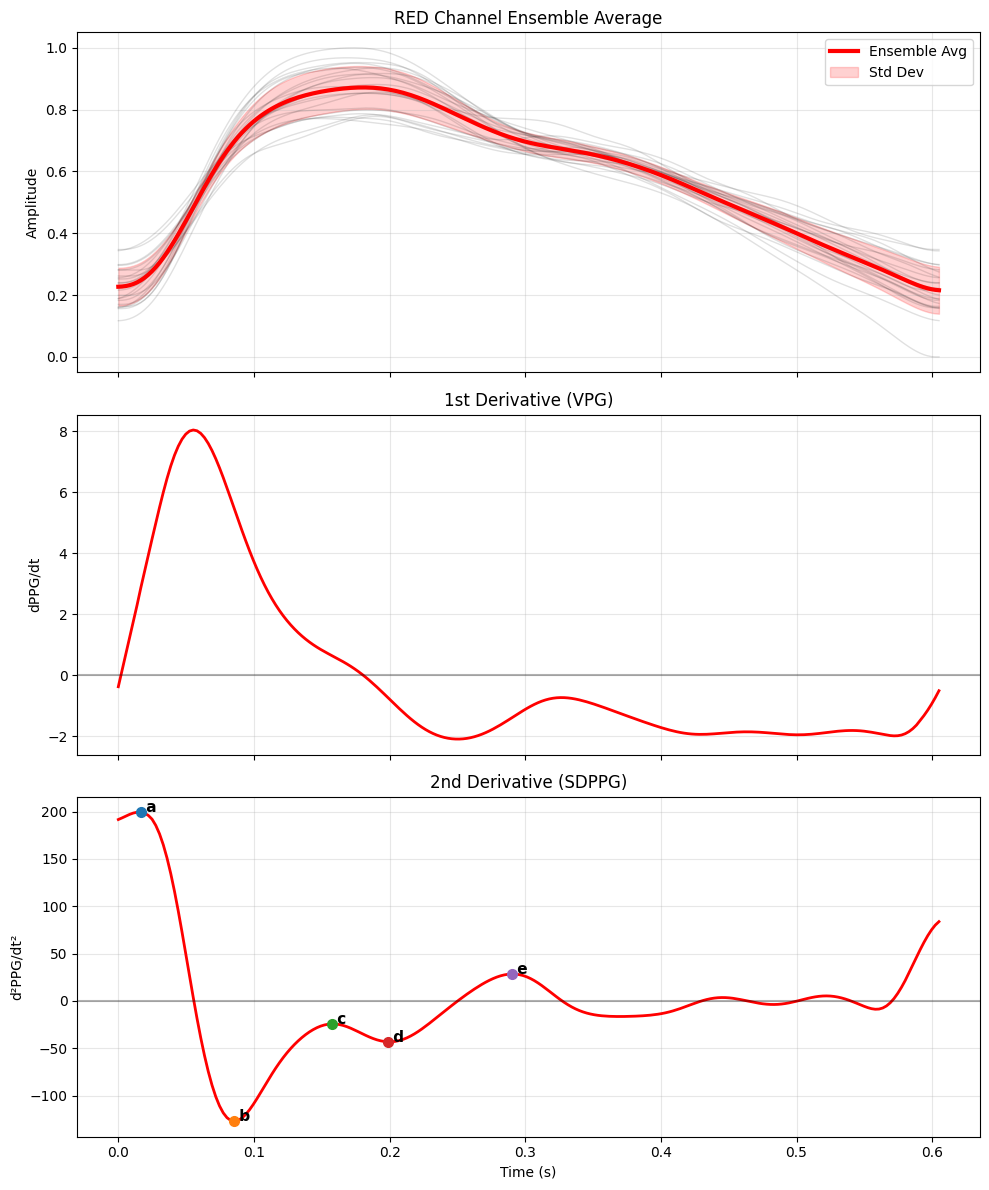

❌ Candidate 1 rejected -> No valid valley was found before this candidate peak. | peak=53
✅ IR Channel: Used 23 beats for ensemble.
   Total segmented pulses: 23
   Rejected candidates   : 1
   Rejected pulses       : 0
   Median beat duration  : 0.605 s


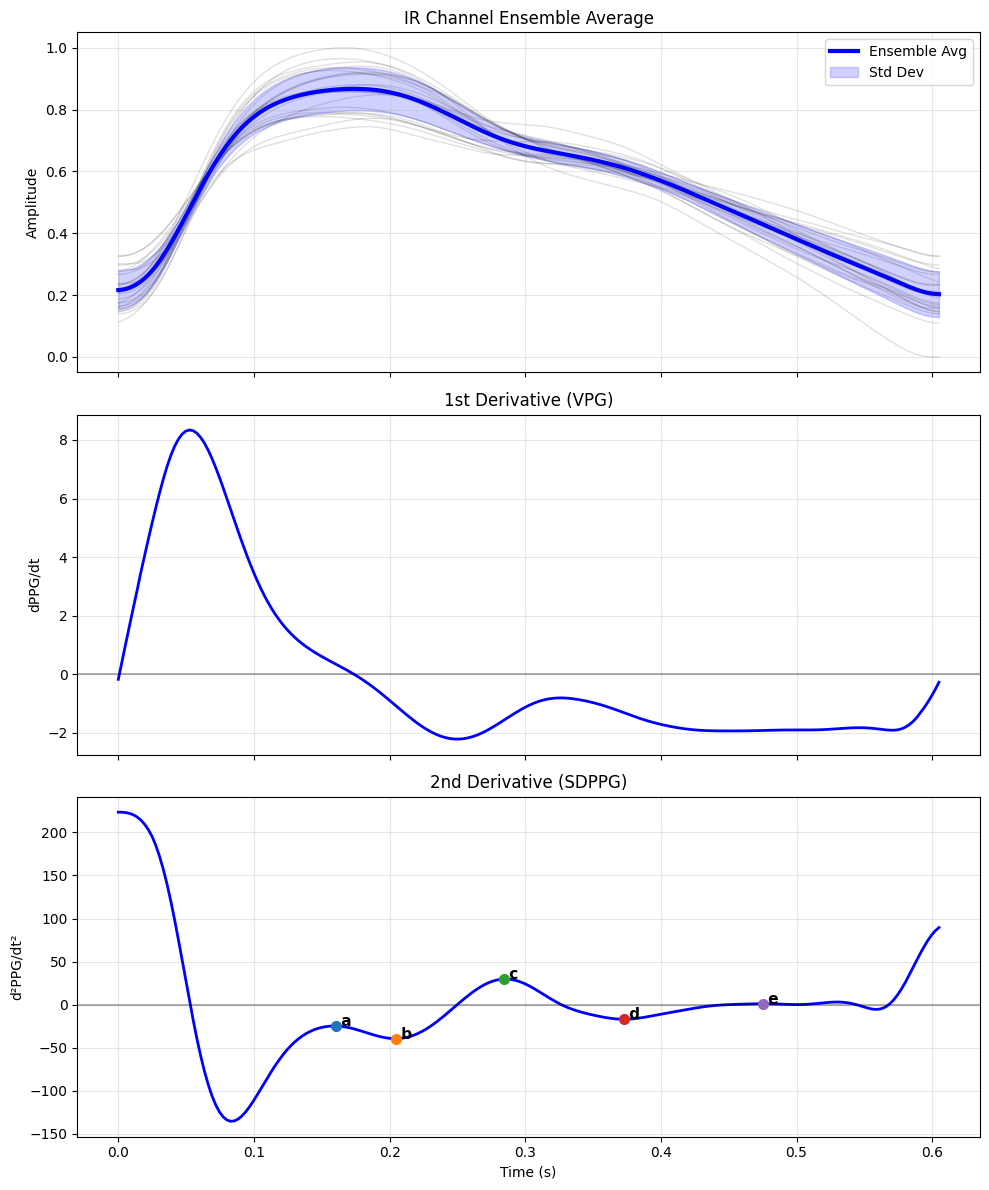


📊 ENSEMBLE SUMMARY
🔴 Red Beats Used: 23
🔵 IR  Beats Used: 23
❌ Candidate 1 rejected -> No valid valley was found before this candidate peak. | peak=56


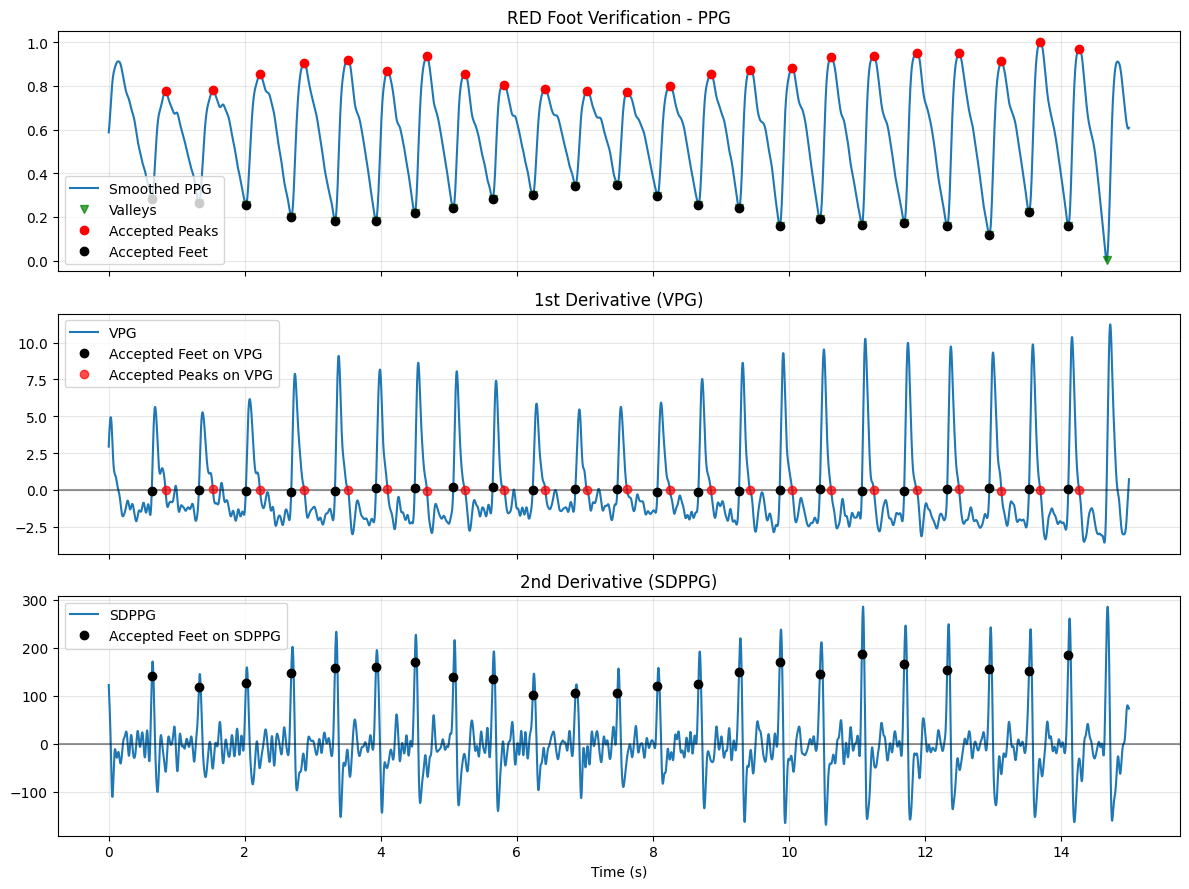


RED Foot Verification summary:
  Total detected peaks         : 25
  Total detected feet          : 24
  Total segmented pulses       : 23
  Valid beats used             : 23
  Rejected candidates          : 1
  Rejected pulses              : 0

  Accepted pulses:
    Pulse 01: foot=253, peak=334, next_foot=530, foot_to_peak=0.203s, VPG@foot=-0.0986
    Pulse 02: foot=530, peak=612, next_foot=806, foot_to_peak=0.205s, VPG@foot=-0.0179
    Pulse 03: foot=806, peak=889, next_foot=1073, foot_to_peak=0.207s, VPG@foot=-0.0704
    Pulse 04: foot=1073, peak=1150, next_foot=1330, foot_to_peak=0.193s, VPG@foot=-0.1186
    Pulse 05: foot=1330, peak=1407, next_foot=1571, foot_to_peak=0.193s, VPG@foot=-0.0937
    Pulse 06: foot=1571, peak=1639, next_foot=1799, foot_to_peak=0.170s, VPG@foot=0.0970
    Pulse 07: foot=1799, peak=1871, next_foot=2026, foot_to_peak=0.180s, VPG@foot=0.0976
    Pulse 08: foot=2026, peak=2094, next_foot=2257, foot_to_peak=0.170s, VPG@foot=0.1606
    Pulse 09: foot=2257, 

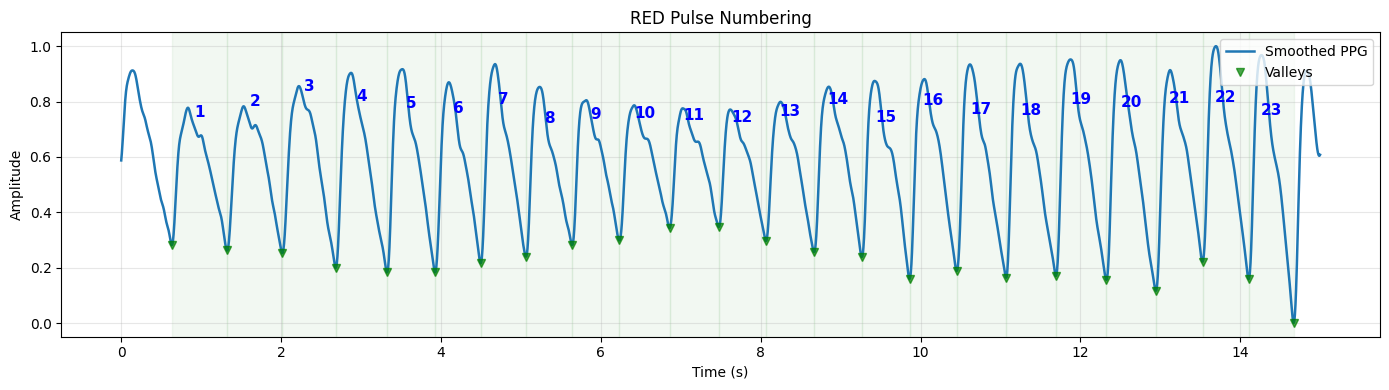


RED Pulse Numbering:
  Total segmented pulses shown on plot: 23
  Pulse 01: ACCEPTED
  Pulse 02: ACCEPTED
  Pulse 03: ACCEPTED
  Pulse 04: ACCEPTED
  Pulse 05: ACCEPTED
  Pulse 06: ACCEPTED
  Pulse 07: ACCEPTED
  Pulse 08: ACCEPTED
  Pulse 09: ACCEPTED
  Pulse 10: ACCEPTED
  Pulse 11: ACCEPTED
  Pulse 12: ACCEPTED
  Pulse 13: ACCEPTED
  Pulse 14: ACCEPTED
  Pulse 15: ACCEPTED
  Pulse 16: ACCEPTED
  Pulse 17: ACCEPTED
  Pulse 18: ACCEPTED
  Pulse 19: ACCEPTED
  Pulse 20: ACCEPTED
  Pulse 21: ACCEPTED
  Pulse 22: ACCEPTED
  Pulse 23: ACCEPTED
❌ Candidate 1 rejected -> No valid valley was found before this candidate peak. | peak=53


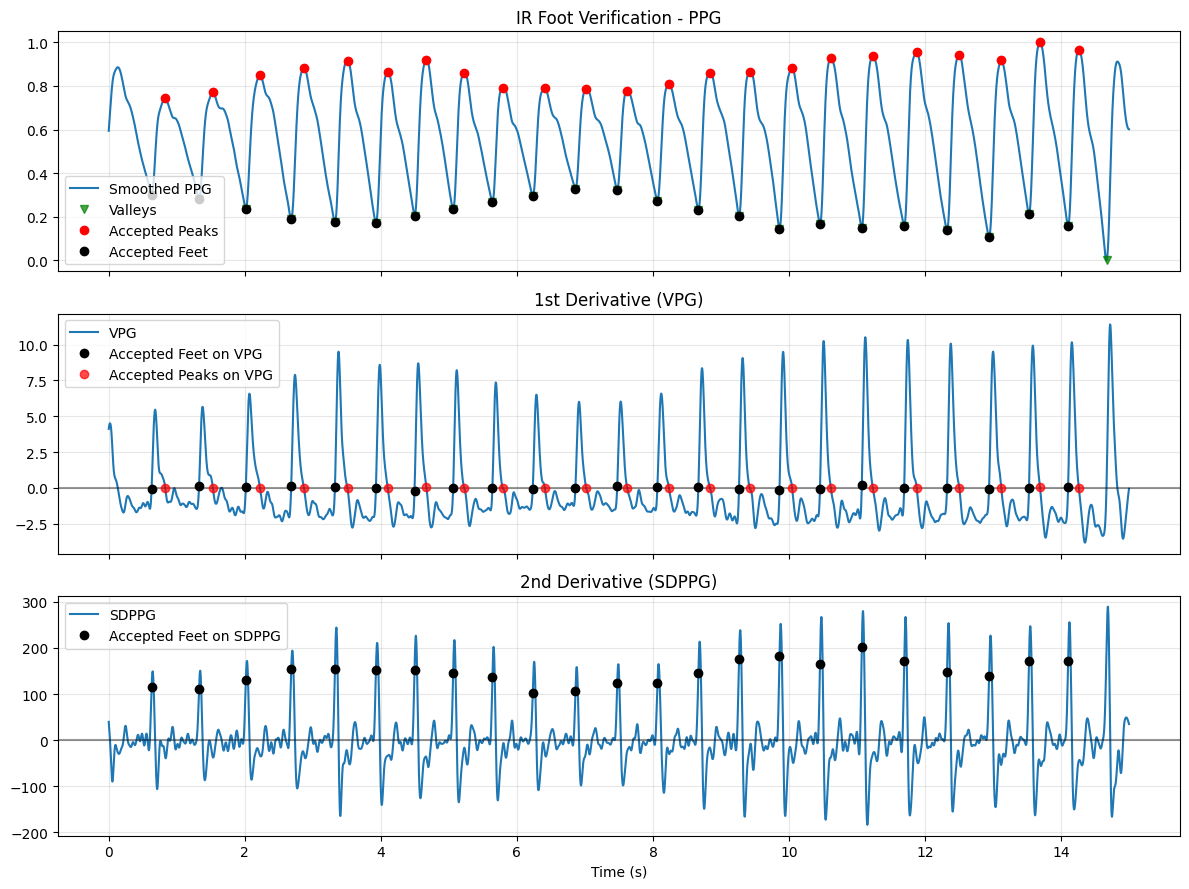


IR Foot Verification summary:
  Total detected peaks         : 25
  Total detected feet          : 24
  Total segmented pulses       : 23
  Valid beats used             : 23
  Rejected candidates          : 1
  Rejected pulses              : 0

  Accepted pulses:
    Pulse 01: foot=252, peak=332, next_foot=531, foot_to_peak=0.200s, VPG@foot=-0.0395
    Pulse 02: foot=531, peak=612, next_foot=806, foot_to_peak=0.203s, VPG@foot=0.1116
    Pulse 03: foot=806, peak=889, next_foot=1073, foot_to_peak=0.207s, VPG@foot=0.0608
    Pulse 04: foot=1073, peak=1148, next_foot=1330, foot_to_peak=0.188s, VPG@foot=0.1507
    Pulse 05: foot=1330, peak=1404, next_foot=1571, foot_to_peak=0.185s, VPG@foot=0.0667
    Pulse 06: foot=1571, peak=1640, next_foot=1798, foot_to_peak=0.172s, VPG@foot=-0.0027
    Pulse 07: foot=1798, peak=1868, next_foot=2025, foot_to_peak=0.175s, VPG@foot=-0.1788
    Pulse 08: foot=2025, peak=2090, next_foot=2256, foot_to_peak=0.163s, VPG@foot=-0.0358
    Pulse 09: foot=2256, pe

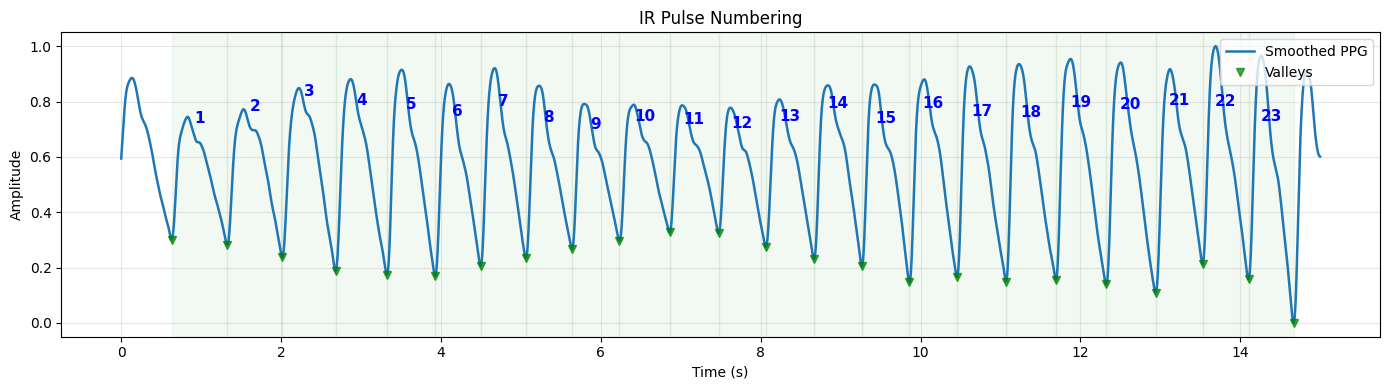


IR Pulse Numbering:
  Total segmented pulses shown on plot: 23
  Pulse 01: ACCEPTED
  Pulse 02: ACCEPTED
  Pulse 03: ACCEPTED
  Pulse 04: ACCEPTED
  Pulse 05: ACCEPTED
  Pulse 06: ACCEPTED
  Pulse 07: ACCEPTED
  Pulse 08: ACCEPTED
  Pulse 09: ACCEPTED
  Pulse 10: ACCEPTED
  Pulse 11: ACCEPTED
  Pulse 12: ACCEPTED
  Pulse 13: ACCEPTED
  Pulse 14: ACCEPTED
  Pulse 15: ACCEPTED
  Pulse 16: ACCEPTED
  Pulse 17: ACCEPTED
  Pulse 18: ACCEPTED
  Pulse 19: ACCEPTED
  Pulse 20: ACCEPTED
  Pulse 21: ACCEPTED
  Pulse 22: ACCEPTED
  Pulse 23: ACCEPTED


In [14]:
# ==========================================
# ⚙️ STEP 11: ENSEMBLE AVERAGING + SDPPG a-b-c-d-e
#
# FULL UPDATED VERSION
#
# Features:
# - Strict VPG zero-crossing based foot detection
# - Main peak selected as first valid peak after foot
# - Candidate diagnostics separated from final pulse diagnostics
# - ONE consistent segmented-pulse numbering system
# - Numbering plot shows ALL segmented pulses
# - Keep all complete pulses
# - Reject only truly incomplete boundary pulses
# - Works for BOTH RED and IR
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter


# =========================================================
# 🔧 TUNABLE PARAMETERS
# =========================================================

VERBOSE_REJECTION = True
# If True, rejected candidates and rejected pulses will be printed in the console.

PEAK_MIN_DISTANCE_SEC = 0.40
# Minimum allowed time between two detected peaks.
# Helps prevent multiple peaks being detected inside one pulse.

PEAK_PROM_FACTOR = 0.20
# Peak prominence factor relative to signal standard deviation.
# Higher value = stricter peak detection.

VALLEY_MIN_DISTANCE_SEC = 0.35
# Minimum allowed time between two detected valleys.
# Helps prevent false valleys inside the same pulse.

VALLEY_PROM_FACTOR = 0.10
# Valley prominence factor relative to signal standard deviation.
# Higher value = stricter valley detection.

MIN_FOOT_TO_PEAK_SEC = 0.12
# Minimum allowed time from foot to peak.
# If too small, the foot and peak are probably confused.

MAX_FOOT_TO_PEAK_SEC = 0.4
# Maximum allowed time from foot to peak.
# If too long, the pulse is probably malformed.

MAX_VALLEY_TO_FOOT_SEC = 0.20
# Maximum allowed time from valley to refined foot.
# Prevents the foot from drifting too far right.

MAX_FOOT_REL_HEIGHT = 0.20
# Maximum allowed relative foot height within the pulse.
# Foot should stay near the bottom of the pulse, not high on the upslope.

MAX_ABS_VPG_AT_FOOT = 0.5
# Maximum allowed absolute VPG value at the foot.
# Since the foot should be near the VPG zero-crossing, this should stay small.

EDGE_EXCLUSION_SEC = 0.1
# Ignore candidate peaks too close to the start or end of the signal.
# Lowered so near-edge complete pulses can still be considered.

MIN_BEAT_DURATION_SEC = 0.35
# Minimum allowed duration of a full beat (foot to next foot).

MAX_BEAT_DURATION_SEC = 1.50
# Maximum allowed duration of a full beat (foot to next foot).

MAIN_PEAK_SEARCH_WINDOW_SEC = 0.3
# After a foot is found, search for the main systolic peak only within this time window.
# This helps avoid selecting a later diastolic/secondary peak.

MAIN_PEAK_MIN_DELAY_SEC = 0.02
# Ignore tiny immediate oscillations right after the foot before choosing the main peak.

START_INCOMPLETE_MARGIN_SEC = 0.10
# Reject a pulse only if its foot is too close to the start of the signal.

END_INCOMPLETE_MARGIN_SEC = 0.01
# Reject a pulse only if its peak or next foot is too close to the end of the signal.


# -----------------------------
# Helper: safe Savitzky-Golay
# -----------------------------
def safe_savgol(x, win, poly=3):
    x = np.asarray(x)
    n = len(x)

    if n < 5:
        return x.copy()

    win = int(win)
    if win % 2 == 0:
        win += 1

    if win >= n:
        win = n - 1 if (n - 1) % 2 == 1 else n - 2

    if win < 5:
        win = 5

    if win >= n or win <= poly:
        return x.copy()

    poly = min(poly, win - 2)
    return savgol_filter(x, window_length=win, polyorder=poly)


# -----------------------------
# Helper: resampling
# -----------------------------
def resample_1d(sig, target_len):
    x_old = np.linspace(0, 1, len(sig))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, sig)


# -----------------------------
# Compute smoothed signal and derivatives
# -----------------------------
def compute_smoothed_derivatives(signal, fs):
    signal = np.asarray(signal)

    win_ppg = max(7, int(0.05 * fs))
    if win_ppg % 2 == 0:
        win_ppg += 1

    smooth_sig = safe_savgol(signal, win_ppg, poly=3)

    vpg = np.gradient(smooth_sig) * fs
    win_vpg = max(5, int(0.03 * fs))
    if win_vpg % 2 == 0:
        win_vpg += 1
    vpg = safe_savgol(vpg, win_vpg, poly=2)

    sdppg = np.gradient(vpg) * fs
    win_sd = max(5, int(0.03 * fs))
    if win_sd % 2 == 0:
        win_sd += 1
    sdppg = safe_savgol(sdppg, win_sd, poly=2)

    return smooth_sig, vpg, sdppg


# -----------------------------
# Easy-to-read candidate reason
# -----------------------------
def explain_candidate_reason(reason_key):
    reason_map = {
        "edge_candidate_peak_start": "Candidate peak is too close to the start of the signal.",
        "edge_candidate_peak_end": "Candidate peak is too close to the end of the signal.",
        "no_left_valley_found": "No valid valley was found before this candidate peak.",
        "valley_too_close_to_peak": "Valley is too close to the candidate peak.",
        "foot_missing": "Foot could not be determined for this candidate.",
        "invalid_ordering": "Invalid ordering inside candidate detection.",
        "pulse_amplitude_non_positive": "Candidate pulse amplitude is not positive.",
        "foot_to_peak_too_short": "Candidate foot-to-peak distance is too short.",
        "foot_to_peak_too_long": "Candidate foot-to-peak distance is too long.",
        "foot_too_far_from_valley": "Candidate foot is too far from valley.",
        "foot_too_high_on_pulse": "Candidate foot is too high on the pulse.",
        "vpg_not_near_zero_at_foot": "VPG at candidate foot is not near zero.",
        "peak_foot_amplitude_too_small": "Candidate amplitude from foot to peak is too small.",
    }
    return reason_map.get(reason_key, reason_key)


# -----------------------------
# Easy-to-read pulse reason
# -----------------------------
def explain_pulse_reason(reason_key):
    reason_map = {
        "no_peak_between_two_feet": "No peak was found between two consecutive feet.",
        "no_main_peak_after_foot": "No valid main systolic peak was found after the foot.",
        "invalid_ordering": "Pulse order is invalid. Expected foot < peak < next foot.",
        "beat_duration_out_of_range": "Beat duration is outside the allowed range.",
        "foot_to_peak_distance_out_of_range": "Foot-to-peak distance is outside the allowed range.",
        "peak_foot_amplitude_too_small": "Amplitude from foot to peak is too small.",
        "upstroke_too_weak": "Upstroke strength is too weak for a reliable pulse.",
        "beat_too_short_after_segmentation": "Segmented beat is too short.",
        "incomplete_at_signal_start": "Pulse is incomplete at the start of the signal.",
        "incomplete_at_signal_end": "Pulse peak is too close to the end of the signal, so the pulse is incomplete.",
        "next_foot_too_close_to_signal_end": "Pulse ends too close to the signal end, so it may be incomplete.",
    }
    return reason_map.get(reason_key, reason_key)


# -----------------------------
# Candidate logger
# -----------------------------
def log_candidate_rejection(rejected_candidates, reason_key, candidate_num=None, **kwargs):
    item = {
        "candidate_num": candidate_num,
        "reason_key": reason_key,
        "reason_text": explain_candidate_reason(reason_key)
    }
    item.update(kwargs)
    rejected_candidates.append(item)

    if VERBOSE_REJECTION:
        if candidate_num is None:
            msg = f"❌ Candidate rejected -> {item['reason_text']}"
        else:
            msg = f"❌ Candidate {candidate_num} rejected -> {item['reason_text']}"
        extra = ", ".join([f"{k}={v}" for k, v in kwargs.items()])
        if extra:
            msg += f" | {extra}"
        print(msg)


# -----------------------------
# Pulse logger
# -----------------------------
def log_pulse_rejection(rejected_pulses, reason_key, pulse_num=None, **kwargs):
    item = {
        "pulse_num": pulse_num,
        "reason_key": reason_key,
        "reason_text": explain_pulse_reason(reason_key)
    }
    item.update(kwargs)
    rejected_pulses.append(item)

    if VERBOSE_REJECTION:
        if pulse_num is None:
            msg = f"❌ Pulse rejected -> {item['reason_text']}"
        else:
            msg = f"❌ Pulse {pulse_num} rejected -> {item['reason_text']}"
        extra = ", ".join([f"{k}={v}" for k, v in kwargs.items()])
        if extra:
            msg += f" | {extra}"
        print(msg)


# -----------------------------
# Find last negative-to-positive zero crossing in VPG
# -----------------------------
def find_last_zero_crossing_before_max(vpg_seg, idx_seg):
    candidates = []

    for i in range(len(vpg_seg) - 1):
        y1 = vpg_seg[i]
        y2 = vpg_seg[i + 1]

        if y1 < 0 and y2 >= 0:
            if abs(y1) <= abs(y2):
                candidates.append(int(idx_seg[i]))
            else:
                candidates.append(int(idx_seg[i + 1]))

    if len(candidates) == 0:
        return None

    return int(candidates[-1])


# -----------------------------
# Foot refinement
# -----------------------------
def refine_foot_zero_crossing(valley_idx, peak_idx, smooth_sig, vpg, sdppg, fs):
    if peak_idx <= valley_idx + 3:
        return int(valley_idx)

    seg_idx = np.arange(valley_idx, peak_idx + 1)
    if len(seg_idx) < 6:
        return int(valley_idx)

    seg_vpg = vpg[seg_idx]

    i_vpgmax_local = int(np.argmax(seg_vpg))
    i_vpgmax = int(seg_idx[i_vpgmax_local])

    if i_vpgmax <= valley_idx + 1:
        return int(valley_idx)

    search_idx = np.arange(valley_idx, i_vpgmax + 1)
    search_vpg = vpg[search_idx]
    search_sdppg = sdppg[search_idx]

    if len(search_idx) < 3:
        return int(valley_idx)

    foot_zero = find_last_zero_crossing_before_max(search_vpg, search_idx)

    if foot_zero is None:
        early_end = max(3, int(0.6 * len(search_idx)))
        early_idx = search_idx[:early_end]
        early_vpg = search_vpg[:early_end]
        foot_zero = int(early_idx[np.argmin(np.abs(early_vpg))])

    foot = int(foot_zero)

    sdppg_peak = int(search_idx[np.argmax(search_sdppg)])
    if foot > sdppg_peak:
        left_part = search_idx[search_idx <= sdppg_peak]
        if len(left_part) > 0:
            foot = int(left_part[np.argmin(np.abs(vpg[left_part]))])

    foot = max(valley_idx, min(foot, i_vpgmax - 1))
    return int(foot)


# -----------------------------
# Choose main peak after foot
# -----------------------------
def select_main_peak_after_foot(candidate_peaks, foot_idx, smooth_sig, fs):
    if len(candidate_peaks) == 0:
        return None

    min_idx = foot_idx + int(MAIN_PEAK_MIN_DELAY_SEC * fs)
    max_idx = foot_idx + int(MAIN_PEAK_SEARCH_WINDOW_SEC * fs)

    valid_peaks = candidate_peaks[(candidate_peaks >= min_idx) & (candidate_peaks <= max_idx)]

    if len(valid_peaks) == 0:
        return None

    return int(valid_peaks[0])


# -----------------------------
# Peak-foot validity
# -----------------------------
def is_valid_peak_foot_pair(foot_idx, peak_idx, valley_idx, smooth_sig, fs):
    if foot_idx is None:
        return False, "foot_missing"

    if not (0 <= valley_idx <= foot_idx < peak_idx < len(smooth_sig)):
        return False, "invalid_ordering"

    foot_to_peak_sec = (peak_idx - foot_idx) / fs

    if foot_to_peak_sec < MIN_FOOT_TO_PEAK_SEC:
        return False, "foot_to_peak_too_short"

    if foot_to_peak_sec > MAX_FOOT_TO_PEAK_SEC:
        return False, "foot_to_peak_too_long"

    amp = smooth_sig[peak_idx] - smooth_sig[foot_idx]
    if amp <= max(0.01, 0.02 * np.std(smooth_sig)):
        return False, "peak_foot_amplitude_too_small"

    return True, "ok"


# -----------------------------
# Ambiguity rejection
# -----------------------------
def is_ambiguous_foot_peak_pair(foot_idx, peak_idx, valley_idx, smooth_sig, vpg, fs):
    if foot_idx is None:
        return True, "foot_missing"

    if not (0 <= valley_idx <= foot_idx < peak_idx < len(smooth_sig)):
        return True, "invalid_ordering"

    foot_to_peak_sec = (peak_idx - foot_idx) / fs
    valley_to_foot_sec = (foot_idx - valley_idx) / fs

    peak_amp = smooth_sig[peak_idx]
    foot_amp = smooth_sig[foot_idx]
    valley_amp = smooth_sig[valley_idx]

    pulse_amp = peak_amp - valley_amp
    if pulse_amp <= 0:
        return True, "pulse_amplitude_non_positive"

    if foot_to_peak_sec < MIN_FOOT_TO_PEAK_SEC:
        return True, "foot_to_peak_too_short"

    if foot_to_peak_sec > MAX_FOOT_TO_PEAK_SEC:
        return True, "foot_to_peak_too_long"

    if valley_to_foot_sec > MAX_VALLEY_TO_FOOT_SEC:
        return True, "foot_too_far_from_valley"

    rel_height = (foot_amp - valley_amp) / pulse_amp
    if rel_height > MAX_FOOT_REL_HEIGHT:
        return True, "foot_too_high_on_pulse"

    if abs(vpg[foot_idx]) > MAX_ABS_VPG_AT_FOOT:
        return True, "vpg_not_near_zero_at_foot"

    return False, "ok"


# -----------------------------
# Beat-level validation
# -----------------------------
def is_valid_beat(foot_idx, peak_idx, next_foot_idx, smooth_sig, vpg, fs):
    if not (0 <= foot_idx < peak_idx < next_foot_idx < len(smooth_sig)):
        return False, "invalid_ordering"

    beat_duration_sec = (next_foot_idx - foot_idx) / fs
    foot_to_peak_sec = (peak_idx - foot_idx) / fs
    amp = smooth_sig[peak_idx] - smooth_sig[foot_idx]

    upstroke_max = np.max(vpg[foot_idx:peak_idx + 1]) if peak_idx > foot_idx else 0.0

    if not (MIN_BEAT_DURATION_SEC <= beat_duration_sec <= MAX_BEAT_DURATION_SEC):
        return False, "beat_duration_out_of_range"

    if not (MIN_FOOT_TO_PEAK_SEC <= foot_to_peak_sec <= MAX_FOOT_TO_PEAK_SEC):
        return False, "foot_to_peak_distance_out_of_range"

    if amp <= max(0.01, 0.02 * np.std(smooth_sig)):
        return False, "peak_foot_amplitude_too_small"

    if upstroke_max <= max(0.05, 0.05 * np.std(vpg)):
        return False, "upstroke_too_weak"

    return True, "ok"


# -----------------------------
# Check true boundary incompleteness
# -----------------------------
def is_incomplete_edge_pulse(foot_idx, peak_idx, next_foot_idx, signal_len, fs):
    start_margin = int(START_INCOMPLETE_MARGIN_SEC * fs)
    end_margin = int(END_INCOMPLETE_MARGIN_SEC * fs)

    if foot_idx < start_margin:
        return True, "incomplete_at_signal_start"

    if peak_idx > signal_len - end_margin:
        return True, "incomplete_at_signal_end"

    if next_foot_idx > signal_len - end_margin:
        return True, "next_foot_too_close_to_signal_end"

    return False, "ok"


# -----------------------------
# Build candidate foots from peaks
# -----------------------------
def build_candidate_foot_peak_pairs(smooth_sig, vpg, sdppg, peaks, valleys, fs):
    candidate_pairs = []
    rejected_candidates = []
    n = len(smooth_sig)

    candidate_num = 0

    for p in peaks:
        p = int(p)
        candidate_num += 1

        if p < int(EDGE_EXCLUSION_SEC * fs):
            log_candidate_rejection(rejected_candidates, "edge_candidate_peak_start", candidate_num=candidate_num, peak=p)
            continue

        if p > n - int(EDGE_EXCLUSION_SEC * fs):
            log_candidate_rejection(rejected_candidates, "edge_candidate_peak_end", candidate_num=candidate_num, peak=p)
            continue

        left_valleys = valleys[valleys < p]
        if len(left_valleys) == 0:
            log_candidate_rejection(rejected_candidates, "no_left_valley_found", candidate_num=candidate_num, peak=p)
            continue

        valley_idx = int(left_valleys[-1])

        if (p - valley_idx) < int(MIN_FOOT_TO_PEAK_SEC * fs):
            log_candidate_rejection(
                rejected_candidates,
                "valley_too_close_to_peak",
                candidate_num=candidate_num,
                peak=p,
                valley=valley_idx
            )
            continue

        refined_foot = refine_foot_zero_crossing(
            valley_idx=valley_idx,
            peak_idx=p,
            smooth_sig=smooth_sig,
            vpg=vpg,
            sdppg=sdppg,
            fs=fs
        )

        ambiguous, ambiguity_reason = is_ambiguous_foot_peak_pair(
            refined_foot, p, valley_idx, smooth_sig, vpg, fs
        )
        if ambiguous:
            log_candidate_rejection(
                rejected_candidates,
                ambiguity_reason,
                candidate_num=candidate_num,
                peak=p,
                foot=refined_foot,
                valley=valley_idx,
                vpg_at_foot=float(vpg[refined_foot]) if refined_foot is not None else None
            )
            continue

        valid_pair, invalid_reason = is_valid_peak_foot_pair(
            refined_foot, p, valley_idx, smooth_sig, fs
        )
        if not valid_pair:
            log_candidate_rejection(
                rejected_candidates,
                invalid_reason,
                candidate_num=candidate_num,
                peak=p,
                foot=refined_foot,
                valley=valley_idx
            )
            continue

        candidate_pairs.append({
            "candidate_num": candidate_num,
            "peak": p,
            "foot": refined_foot,
            "valley": valley_idx
        })

    return candidate_pairs, rejected_candidates


# -----------------------------
# Main detection
# -----------------------------
def detect_beats_foot_to_foot(signal_data, fs):
    smooth_sig, vpg, sdppg = compute_smoothed_derivatives(signal_data, fs)

    peaks, _ = find_peaks(
        smooth_sig,
        distance=int(PEAK_MIN_DISTANCE_SEC * fs),
        prominence=max(0.015, np.std(smooth_sig) * PEAK_PROM_FACTOR)
    )

    valleys, _ = find_peaks(
        -smooth_sig,
        distance=int(VALLEY_MIN_DISTANCE_SEC * fs),
        prominence=max(0.01, np.std(smooth_sig) * VALLEY_PROM_FACTOR)
    )

    candidate_pairs, rejected_candidates = build_candidate_foot_peak_pairs(
        smooth_sig, vpg, sdppg, peaks, valleys, fs
    )

    if len(candidate_pairs) == 0:
        return (
            peaks, np.array([]), [], [], [],
            smooth_sig, vpg, sdppg, valleys,
            rejected_candidates, [], []
        )

    feet = []
    feet_seen = set()

    for item in candidate_pairs:
        f = int(item["foot"])
        if f not in feet_seen:
            feet.append(f)
            feet_seen.add(f)

    feet = np.array(sorted(feet), dtype=int)

    segmented_pulses_all = []
    for i in range(len(feet) - 1):
        f1 = int(feet[i])
        f2 = int(feet[i + 1])
        segmented_pulses_all.append({
            "pulse_num": i + 1,
            "foot": f1,
            "next_foot": f2,
            "mid_idx": int((f1 + f2) // 2),
            "status": "unknown",
            "reason_text": ""
        })

    beats = []
    valid_feet = []
    beat_info = []
    rejected_pulses = []

    for seg in segmented_pulses_all:
        pulse_num = seg["pulse_num"]
        f1 = seg["foot"]
        f2 = seg["next_foot"]

        candidate_peaks = peaks[(peaks > f1) & (peaks < f2)]
        if len(candidate_peaks) == 0:
            seg["status"] = "rejected"
            seg["reason_text"] = explain_pulse_reason("no_peak_between_two_feet")
            log_pulse_rejection(
                rejected_pulses,
                "no_peak_between_two_feet",
                pulse_num=pulse_num,
                foot=f1,
                next_foot=f2
            )
            continue

        p = select_main_peak_after_foot(candidate_peaks, f1, smooth_sig, fs)
        if p is None:
            seg["status"] = "rejected"
            seg["reason_text"] = explain_pulse_reason("no_main_peak_after_foot")
            log_pulse_rejection(
                rejected_pulses,
                "no_main_peak_after_foot",
                pulse_num=pulse_num,
                foot=f1,
                next_foot=f2
            )
            continue

        edge_incomplete, edge_reason = is_incomplete_edge_pulse(
            foot_idx=f1,
            peak_idx=p,
            next_foot_idx=f2,
            signal_len=len(smooth_sig),
            fs=fs
        )
        if edge_incomplete:
            seg["status"] = "rejected"
            seg["reason_text"] = explain_pulse_reason(edge_reason)
            log_pulse_rejection(
                rejected_pulses,
                edge_reason,
                pulse_num=pulse_num,
                foot=f1,
                peak=p,
                next_foot=f2
            )
            continue

        valid_beat, beat_reason = is_valid_beat(f1, p, f2, smooth_sig, vpg, fs)
        if not valid_beat:
            seg["status"] = "rejected"
            seg["reason_text"] = explain_pulse_reason(beat_reason)
            log_pulse_rejection(
                rejected_pulses,
                beat_reason,
                pulse_num=pulse_num,
                peak=p,
                foot=f1,
                next_foot=f2
            )
            continue

        beat = signal_data[f1:f2 + 1]
        if len(beat) <= 10:
            seg["status"] = "rejected"
            seg["reason_text"] = explain_pulse_reason("beat_too_short_after_segmentation")
            log_pulse_rejection(
                rejected_pulses,
                "beat_too_short_after_segmentation",
                pulse_num=pulse_num,
                peak=p,
                foot=f1,
                next_foot=f2,
                beat_len=len(beat)
            )
            continue

        seg["status"] = "accepted"

        beats.append(beat)
        valid_feet.append((f1, f2))

        beat_info.append({
            "pulse_num": pulse_num,
            "foot": f1,
            "peak": p,
            "next_foot": f2,
            "mid_idx": int((f1 + f2) // 2),
            "beat_duration": float((f2 - f1) / fs),
            "foot_to_peak_sec": float((p - f1) / fs),
            "amplitude": float(smooth_sig[p] - smooth_sig[f1]),
            "vpg_at_foot": float(vpg[f1]),
            "sdppg_at_foot": float(sdppg[f1]),
            "status": "accepted"
        })

    pulse_map = []
    for seg in segmented_pulses_all:
        pulse_map.append({
            "pulse_num": seg["pulse_num"],
            "foot": seg["foot"],
            "next_foot": seg["next_foot"],
            "mid_idx": seg["mid_idx"],
            "status": seg["status"],
            "reason_text": seg["reason_text"]
        })

    return (
        peaks, feet, beats, valid_feet, beat_info,
        smooth_sig, vpg, sdppg, valleys,
        rejected_candidates, rejected_pulses, pulse_map
    )


# -----------------------------
# Ensemble averaging
# -----------------------------
def build_ensemble_from_beats(beats, target_len=200):
    if len(beats) == 0:
        return None, None, None

    beats_rs = np.array([resample_1d(b, target_len) for b in beats])
    avg_wave = np.mean(beats_rs, axis=0)
    std_wave = np.std(beats_rs, axis=0)

    return beats_rs, avg_wave, std_wave


# -----------------------------
# Alignment by VPG max
# -----------------------------
def align_beats_by_vpg(beats_rs, fs_eff):
    if beats_rs is None or len(beats_rs) == 0:
        return beats_rs

    vpg_all = np.gradient(beats_rs, axis=1) * fs_eff
    vpg_all = np.array([
        safe_savgol(v, max(5, int(0.03 * fs_eff)), poly=2)
        for v in vpg_all
    ])

    ref_idx = int(np.argmax(np.mean(vpg_all, axis=0)))

    aligned = []
    for i in range(len(beats_rs)):
        vpg_i = vpg_all[i]
        idx_i = int(np.argmax(vpg_i))
        shift = ref_idx - idx_i

        shifted = np.roll(beats_rs[i], shift)

        if shift > 0:
            shifted[:shift] = shifted[shift]
        elif shift < 0:
            shifted[shift:] = shifted[shift - 1]

        aligned.append(shifted)

    return np.array(aligned)


# -----------------------------
# Derivatives for ensemble average
# -----------------------------
def compute_derivatives(signal, fs_eff):
    smooth = safe_savgol(signal, max(7, int(0.05 * fs_eff)), poly=3)

    vpg = np.gradient(smooth) * fs_eff
    vpg = safe_savgol(vpg, max(5, int(0.03 * fs_eff)), poly=2)

    sdppg = np.gradient(vpg) * fs_eff
    sdppg = safe_savgol(sdppg, max(5, int(0.03 * fs_eff)), poly=2)

    return vpg, sdppg


# -----------------------------
# SDPPG fiducials
# -----------------------------
def detect_sdppg_abcde(sdppg, fs_eff):
    n = len(sdppg)

    win = max(7, int(0.05 * fs_eff))
    if win % 2 == 0:
        win += 1
    if win >= n:
        win = n - 1 if (n - 1) % 2 == 1 else n - 2
    if win < 5:
        win = 5

    sd_s = safe_savgol(sdppg, win, poly=3)

    pos_peaks, _ = find_peaks(sd_s, distance=max(3, int(0.05 * fs_eff)))
    neg_peaks, _ = find_peaks(-sd_s, distance=max(3, int(0.05 * fs_eff)))

    fid = {"a": None, "b": None, "c": None, "d": None, "e": None}

    if len(pos_peaks) == 0:
        return fid, sd_s

    early_pos = pos_peaks[pos_peaks < int(0.35 * n)]
    if len(early_pos) == 0:
        return fid, sd_s

    a = int(early_pos[np.argmax(sd_s[early_pos])])
    fid["a"] = a

    b_candidates = neg_peaks[neg_peaks > a]
    if len(b_candidates) == 0:
        return fid, sd_s
    b = int(b_candidates[0])
    fid["b"] = b

    c_candidates = pos_peaks[pos_peaks > b]
    if len(c_candidates) == 0:
        return fid, sd_s
    c = int(c_candidates[0])
    fid["c"] = c

    d_candidates = neg_peaks[neg_peaks > c]
    if len(d_candidates) == 0:
        return fid, sd_s
    d = int(d_candidates[0])
    fid["d"] = d

    e_candidates = pos_peaks[pos_peaks > d]
    if len(e_candidates) > 0:
        fid["e"] = int(e_candidates[0])

    return fid, sd_s


# -----------------------------
# Numbering plot
# -----------------------------
def plot_pulse_numbering(signal_data, fs, title="Pulse Numbering"):
    (
        peaks, feet, beats, valid_feet, beat_info,
        smooth_sig, vpg, sdppg, valleys,
        rejected_candidates, rejected_pulses, pulse_map
    ) = detect_beats_foot_to_foot(signal_data, fs)

    t = np.arange(len(signal_data)) / fs

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, smooth_sig, label="Smoothed PPG", linewidth=1.8)

    if len(valleys):
        ax.plot(t[valleys], smooth_sig[valleys], "gv", alpha=0.7, label="Valleys")

    for item in pulse_map:
        pulse_num = item["pulse_num"]
        mid_idx = item["mid_idx"]
        y = smooth_sig[mid_idx]

        if item["status"] == "accepted":
            ax.text(
                t[mid_idx], y + 0.06, str(pulse_num),
                color="blue", fontsize=11, fontweight="bold",
                ha="center", va="bottom"
            )
            ax.axvspan(t[item["foot"]], t[item["next_foot"]], alpha=0.05, color="green")
        else:
            ax.text(
                t[mid_idx], y + 0.06, str(pulse_num),
                color="red", fontsize=11, fontweight="bold",
                ha="center", va="bottom"
            )
            ax.axvspan(t[item["foot"]], t[item["next_foot"]], alpha=0.10, color="red")

    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    print(f"\n{title}:")
    print(f"  Total segmented pulses shown on plot: {len(pulse_map)}")
    for item in pulse_map:
        if item["status"] == "accepted":
            print(f"  Pulse {item['pulse_num']:02d}: ACCEPTED")
        else:
            print(f"  Pulse {item['pulse_num']:02d}: REJECTED -> {item.get('reason_text', 'Unknown reason')}")


# -----------------------------
# Plot ensemble
# -----------------------------
def plot_ensemble_sdppg(signal_data, fs, title, color_avg, target_len=220):
    (
        peaks, feet, beats, valid_feet, beat_info,
        smooth_sig, vpg_raw, sdppg_raw, valleys,
        rejected_candidates, rejected_pulses, pulse_map
    ) = detect_beats_foot_to_foot(signal_data, fs)

    if len(beats) < 3:
        print(f"⚠️ Not enough valid beats in {title}.")
        print(f"   Rejected candidates: {len(rejected_candidates)}")
        print(f"   Rejected pulses    : {len(rejected_pulses)}")
        return None, None, None, None, 0, None, None

    beats_rs, _, _ = build_ensemble_from_beats(beats, target_len=target_len)

    beat_durations = [len(b) / fs for b in beats]
    avg_duration = float(np.median(beat_durations))
    fs_eff = target_len / avg_duration

    beats_rs_aligned = align_beats_by_vpg(beats_rs, fs_eff)

    avg_wave = np.mean(beats_rs_aligned, axis=0)
    std_wave = np.std(beats_rs_aligned, axis=0)

    vpg, sdppg = compute_derivatives(avg_wave, fs_eff)
    fid, sdppg_s = detect_sdppg_abcde(sdppg, fs_eff)

    time_axis = np.linspace(0, avg_duration, target_len)

    meta = {
        "title": title,
        "target_len": int(target_len),
        "beats_used": int(len(beats)),
        "rejected_candidates": int(len(rejected_candidates)),
        "rejected_pulses": int(len(rejected_pulses)),
        "segmented_pulses_total": int(len(pulse_map)),
        "avg_duration": float(avg_duration),
        "fs_eff": float(fs_eff),
        "time_axis": time_axis.copy(),
        "feet": [tuple(map(int, x)) for x in valid_feet],
        "beat_info": beat_info,
        "pulse_map": pulse_map,
        "rejected_candidates_info": rejected_candidates,
        "rejected_pulses_info": rejected_pulses,
        "fiducials": fid.copy()
    }

    print(f"✅ {title}: Used {len(beats)} beats for ensemble.")
    print(f"   Total segmented pulses: {len(pulse_map)}")
    print(f"   Rejected candidates   : {len(rejected_candidates)}")
    print(f"   Rejected pulses       : {len(rejected_pulses)}")
    print(f"   Median beat duration  : {avg_duration:.3f} s")

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    ax1 = axes[0]
    for b in beats_rs_aligned:
        ax1.plot(time_axis, b, color='black', alpha=0.12, linewidth=1)
    ax1.plot(time_axis, avg_wave, color=color_avg, linewidth=3, label='Ensemble Avg')
    ax1.fill_between(time_axis, avg_wave - std_wave, avg_wave + std_wave, color=color_avg, alpha=0.18, label='Std Dev')
    ax1.set_title(f"{title} Ensemble Average")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    ax2 = axes[1]
    ax2.plot(time_axis, vpg, color=color_avg, linewidth=2)
    ax2.axhline(0, color='black', alpha=0.3)
    ax2.set_title("1st Derivative (VPG)")
    ax2.set_ylabel("dPPG/dt")
    ax2.grid(True, alpha=0.3)

    ax3 = axes[2]
    ax3.plot(time_axis, sdppg_s, color=color_avg, linewidth=2)
    ax3.axhline(0, color='black', alpha=0.3)
    ax3.set_title("2nd Derivative (SDPPG)")
    ax3.set_ylabel("d²PPG/dt²")
    ax3.set_xlabel("Time (s)")
    ax3.grid(True, alpha=0.3)

    for name in ["a", "b", "c", "d", "e"]:
        idx = fid[name]
        if idx is not None:
            ax3.plot(time_axis[idx], sdppg_s[idx], 'o', markersize=7)
            ax3.text(time_axis[idx], sdppg_s[idx], f" {name}", fontsize=11, weight='bold')

    plt.tight_layout()
    plt.show()

    return avg_wave, vpg, sdppg_s, beats_rs_aligned, len(beats), fid, meta


# -----------------------------
# Debug plot
# -----------------------------
def debug_plot_feet(signal_data, fs, title="Foot Check"):
    (
        peaks, feet, beats, valid_feet, beat_info,
        smooth_sig, vpg, sdppg, valleys,
        rejected_candidates, rejected_pulses, pulse_map
    ) = detect_beats_foot_to_foot(signal_data, fs)

    t = np.arange(len(signal_data)) / fs

    accepted_peaks = np.array([b["peak"] for b in beat_info], dtype=int) if len(beat_info) else np.array([], dtype=int)
    accepted_feet = np.array([b["foot"] for b in beat_info], dtype=int) if len(beat_info) else np.array([], dtype=int)

    rejected_peaks = np.array([x["peak"] for x in rejected_pulses if "peak" in x and x["peak"] is not None], dtype=int) if len(rejected_pulses) else np.array([], dtype=int)
    rejected_feet = np.array([x["foot"] for x in rejected_pulses if "foot" in x and x["foot"] is not None], dtype=int) if len(rejected_pulses) else np.array([], dtype=int)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(t, smooth_sig, label="Smoothed PPG")
    if len(valleys):
        axes[0].plot(t[valleys], smooth_sig[valleys], "gv", label="Valleys", alpha=0.7)
    if len(accepted_peaks):
        axes[0].plot(t[accepted_peaks], smooth_sig[accepted_peaks], "ro", label="Accepted Peaks")
    if len(accepted_feet):
        axes[0].plot(t[accepted_feet], smooth_sig[accepted_feet], "ko", label="Accepted Feet")
    if len(rejected_peaks):
        axes[0].plot(t[rejected_peaks], smooth_sig[rejected_peaks], "x", color="orange", markersize=8, label="Rejected Peaks")
    axes[0].set_title(title + " - PPG")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(t, vpg, label="VPG")
    axes[1].axhline(0, color="black", alpha=0.4)
    if len(accepted_feet):
        axes[1].plot(t[accepted_feet], vpg[accepted_feet], "ko", label="Accepted Feet on VPG")
    if len(accepted_peaks):
        axes[1].plot(t[accepted_peaks], vpg[accepted_peaks], "ro", label="Accepted Peaks on VPG", alpha=0.7)
    if len(rejected_feet):
        axes[1].plot(t[rejected_feet], vpg[rejected_feet], "x", color="orange", markersize=8, label="Rejected Feet on VPG")
    axes[1].set_title("1st Derivative (VPG)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(t, sdppg, label="SDPPG")
    axes[2].axhline(0, color="black", alpha=0.4)
    if len(accepted_feet):
        axes[2].plot(t[accepted_feet], sdppg[accepted_feet], "ko", label="Accepted Feet on SDPPG")
    if len(rejected_feet):
        axes[2].plot(t[rejected_feet], sdppg[rejected_feet], "x", color="orange", markersize=8, label="Rejected Feet on SDPPG")
    axes[2].set_title("2nd Derivative (SDPPG)")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{title} summary:")
    print(f"  Total detected peaks         : {len(peaks)}")
    print(f"  Total detected feet          : {len(feet)}")
    print(f"  Total segmented pulses       : {len(pulse_map)}")
    print(f"  Valid beats used             : {len(beats)}")
    print(f"  Rejected candidates          : {len(rejected_candidates)}")
    print(f"  Rejected pulses              : {len(rejected_pulses)}")

    if len(beat_info) > 0:
        print("\n  Accepted pulses:")
        for b in beat_info:
            print(
                f"    Pulse {b['pulse_num']:02d}: foot={b['foot']}, peak={b['peak']}, "
                f"next_foot={b['next_foot']}, foot_to_peak={b['foot_to_peak_sec']:.3f}s, "
                f"VPG@foot={b['vpg_at_foot']:.4f}"
            )

    if len(rejected_pulses) > 0:
        print("\n  Rejected pulses:")
        for item in rejected_pulses:
            print(f"    Pulse {item['pulse_num']:02d}: {item['reason_text']}")
            details = {k: v for k, v in item.items() if k not in ['reason_key', 'reason_text', 'pulse_num']}
            if details:
                print(f"             Details: {details}")

    if len(rejected_candidates) > 0:
        print("\n  Rejected candidates (raw peak stage, not pulse numbering):")
        for item in rejected_candidates:
            print(f"    Candidate {item['candidate_num']:02d}: {item['reason_text']}")
            details = {k: v for k, v in item.items() if k not in ['reason_key', 'reason_text', 'candidate_num']}
            if details:
                print(f"               Details: {details}")


# ==========================================
# RUN
# ==========================================

print("\n📉 GENERATING ENSEMBLE (FOOT-TO-FOOT -> VPG ALIGNMENT -> SDPPG)...\n")

avg_wave_red, vpg_red, sdppg_red, beats_red, n_red_beats, fid_red, ensemble_meta_red = plot_ensemble_sdppg(
    red_norm, FS, "RED Channel", "red", target_len=ENSEMBLE_TARGET_LEN
)

avg_wave_ir, vpg_ir, sdppg_ir, beats_ir, n_ir_beats, fid_ir, ensemble_meta_ir = plot_ensemble_sdppg(
    ir_norm, FS, "IR Channel", "blue", target_len=ENSEMBLE_TARGET_LEN
)

print("\n" + "=" * 40)
print("📊 ENSEMBLE SUMMARY")
print(f"🔴 Red Beats Used: {n_red_beats}")
print(f"🔵 IR  Beats Used: {n_ir_beats}")
print("=" * 40)

debug_plot_feet(red_norm, FS, title="RED Foot Verification")
plot_pulse_numbering(red_norm, FS, title="RED Pulse Numbering")

debug_plot_feet(ir_norm, FS, title="IR Foot Verification")
plot_pulse_numbering(ir_norm, FS, title="IR Pulse Numbering")

In [15]:
## Cell 332 — STEP 12: FEATURE EXTRACTION (Ensemble Average)

#```python
# ==========================================
# ⚙️ STEP 12: FEATURE EXTRACTION (Ensemble Average)
# Important fix:
# This cell now uses Step 11 outputs directly.
# It does NOT recompute another ensemble and does NOT overwrite avg_wave_red/ir.
# ==========================================

import numpy as np
import scipy.stats as stats

def extract_features_from_ensemble_wave(beat_wave, global_hr, raw_signal_for_dc, fs_eff):
    """
    Extracts morphology features from the Step 11 ensemble waveform.
    """
    if beat_wave is None:
        return {}

    peak_idx = int(np.argmax(beat_wave))
    half_max = beat_wave[peak_idx] * 0.5

    left, right = peak_idx, peak_idx
    while left > 0 and beat_wave[left] > half_max:
        left -= 1
    while right < len(beat_wave) - 1 and beat_wave[right] > half_max:
        right += 1

    pulse_width = (right - left) / fs_eff

    if hasattr(np, 'trapezoid'):
        area = np.trapezoid(beat_wave)
    else:
        area = np.trapz(beat_wave)

    sys_amp = np.max(beat_wave) - np.min(beat_wave)
    skew = stats.skew(beat_wave)
    kurt = stats.kurtosis(beat_wave)

    ac_global = np.max(raw_signal_for_dc) - np.min(raw_signal_for_dc)
    dc_global = np.mean(raw_signal_for_dc)
    pi = (ac_global / dc_global) * 100 if dc_global > 0 else 0

    return {
        'HR_Global': float(global_hr),
        'Width_Avg': float(pulse_width),
        'Area_Avg':  float(area),
        'Amp_Avg':   float(sys_amp),
        'Skew_Avg':  float(skew),
        'Kurt_Avg':  float(kurt),
        'PI_Global': float(pi)
    }

print("\n🧬 EXTRACTING FEATURES FROM STEP 11 ENSEMBLE AVERAGE...")

if ensemble_meta_red is None or ensemble_meta_ir is None:
    raise ValueError("❌ Step 11 ensemble outputs are missing. Run Cell 331 first.")

final_feat_red = extract_features_from_ensemble_wave(
    avg_wave_red,
    feat_red['hr'],
    selected_df['RED'].values,
    ensemble_meta_red['fs_eff']
)

final_feat_ir = extract_features_from_ensemble_wave(
    avg_wave_ir,
    feat_ir['hr'],
    selected_df['IR'].values,
    ensemble_meta_ir['fs_eff']
)

print("\n" + "=" * 95)
print(f"🌟 GOLDEN STANDARD FEATURE REPORT")
print("=" * 95)
print(f"{'FEATURE':<25} | {'RED (Avg)':<15} | {'IR (Avg)':<15} | {'Significance'}")
print("-" * 95)

print(f"{'Heart Rate':<25} | {final_feat_red['HR_Global']:<15.1f} | {final_feat_ir['HR_Global']:<15.1f} | Global BPM")
print(f"{'Pulse Width':<25} | {final_feat_red['Width_Avg']:<15.4f} | {final_feat_ir['Width_Avg']:<15.4f} | *Viscosity Indicator*")
print(f"{'Area Under Curve':<25} | {final_feat_red['Area_Avg']:<15.4f} | {final_feat_ir['Area_Avg']:<15.4f} | Blood Volume Profile")
print(f"{'Skewness':<25} | {final_feat_red['Skew_Avg']:<15.4f} | {final_feat_ir['Skew_Avg']:<15.4f} | Wave Symmetry")
print(f"{'Kurtosis':<25} | {final_feat_red['Kurt_Avg']:<15.4f} | {final_feat_ir['Kurt_Avg']:<15.4f} | Peak Sharpness")
print(f"{'Perfusion Index':<25} | {final_feat_red['PI_Global']:<15.4f} | {final_feat_ir['PI_Global']:<15.4f} | Signal Strength (%)")
print("=" * 95)
#```

#---


🧬 EXTRACTING FEATURES FROM STEP 11 ENSEMBLE AVERAGE...

🌟 GOLDEN STANDARD FEATURE REPORT
FEATURE                   | RED (Avg)       | IR (Avg)        | Significance
-----------------------------------------------------------------------------------------------
Heart Rate                | 98.0            | 98.0            | Global BPM
Pulse Width               | 0.4345          | 0.4235          | *Viscosity Indicator*
Area Under Curve          | 128.4374        | 126.4944        | Blood Volume Profile
Skewness                  | -0.2610         | -0.2397         | Wave Symmetry
Kurtosis                  | -1.2301         | -1.2386         | Peak Sharpness
Perfusion Index           | 0.8430          | 2.2458          | Signal Strength (%)


In [16]:
## Cell 333 — Matplotlib backend helper

#```python
# If you're in VSCode/Jupyter and plots don't respond, this backend is the key.
# Try ipympl first, fallback to inline if not available

try:
    get_ipython().run_line_magic('matplotlib', 'ipympl')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt
plt.ioff()
#```

#---

In [17]:
# ==========================================
# 💾 STEP 13: SAVE PROCESSED DATA & CHECKPOINTING
# Fresh path construction inside do_save()
# Avoids stale Jupyter variable/callback issues
# ==========================================

import os
import json
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n" + "=" * 60)
print("💾 DATA EXPORT & CHECKPOINTING")
print("=" * 60)

# -------------------------------------------------
# EXACT OUTPUT ROOT PATH
# CHANGE ONLY THIS LINE WHEN NEEDED
# -------------------------------------------------
SAVE_ROOT_FIXED = r"C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\04_Filtered"

print(f"\n✅ Fixed output root set to:\n{SAVE_ROOT_FIXED}")

out = widgets.Output()

btn_save = widgets.Button(description="✅ Save Files", button_style="success")
btn_cancel = widgets.Button(description="❌ Cancel", button_style="danger")
btn_box = widgets.HBox([btn_save, btn_cancel])


# -------------------------------------------------
# JSON SAFE CONVERTER
# -------------------------------------------------
def to_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): to_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_json_safe(v) for v in obj]
    elif isinstance(obj, tuple):
        return [to_json_safe(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif pd.isna(obj):
        return None
    else:
        return obj


# -------------------------------------------------
# VALIDATE ENSEMBLE DATA
# -------------------------------------------------
def validate_ensemble_consistency():
    if ensemble_meta_red is None or ensemble_meta_ir is None:
        raise ValueError("❌ Step 11 ensemble metadata missing. Run Cell 331 first.")

    red_lens = (
        len(avg_wave_red),
        len(vpg_red),
        len(sdppg_red),
        len(ensemble_meta_red["time_axis"])
    )

    ir_lens = (
        len(avg_wave_ir),
        len(vpg_ir),
        len(sdppg_ir),
        len(ensemble_meta_ir["time_axis"])
    )

    print(f"RED lengths -> Avg:{red_lens[0]}, VPG:{red_lens[1]}, SDPPG:{red_lens[2]}, Time:{red_lens[3]}")
    print(f"IR  lengths -> Avg:{ir_lens[0]}, VPG:{ir_lens[1]}, SDPPG:{ir_lens[2]}, Time:{ir_lens[3]}")

    if len(set(red_lens)) != 1:
        raise ValueError(f"❌ RED ensemble mismatch: {red_lens}")

    if len(set(ir_lens)) != 1:
        raise ValueError(f"❌ IR ensemble mismatch: {ir_lens}")


# -------------------------------------------------
# PAD ARRAYS
# -------------------------------------------------
def make_padded_column(arr, target_len):
    arr = np.asarray(arr, dtype=float)
    out_arr = np.full(target_len, np.nan, dtype=float)
    out_arr[:len(arr)] = arr
    return out_arr


# -------------------------------------------------
# BUILD SAVE PATHS FRESH EACH TIME
# -------------------------------------------------
def build_save_paths():
    save_root = os.path.abspath(SAVE_ROOT_FIXED.strip())

    filename_no_ext = os.path.splitext(os.path.basename(FILENAME))[0]

    if "_Win" in filename_no_ext:
        subject_prefix = filename_no_ext.split("_Win")[0]
    else:
        subject_prefix = filename_no_ext

    folder_level1 = f"{subject_prefix}_Filtered"
    folder_level2 = f"{filename_no_ext}_Filtered"

    path_level1 = os.path.join(save_root, folder_level1)
    full_save_path = os.path.join(path_level1, folder_level2)

    file_full = f"{filename_no_ext}_Filtered_Full.csv"
    file_ensemble = f"{filename_no_ext}_Filtered_Ensemble.csv"
    file_config = f"{filename_no_ext}_Filtered_Configuration.json"

    return {
        "save_root": save_root,
        "filename_no_ext": filename_no_ext,
        "subject_prefix": subject_prefix,
        "folder_level1": folder_level1,
        "folder_level2": folder_level2,
        "path_level1": os.path.abspath(path_level1),
        "full_save_path": os.path.abspath(full_save_path),
        "file_full": file_full,
        "file_ensemble": file_ensemble,
        "file_config": file_config,
    }


# -------------------------------------------------
# SAFETY CHECK
# -------------------------------------------------
def ensure_path_is_inside_root(root_path, target_path):
    root_path = os.path.abspath(root_path)
    target_path = os.path.abspath(target_path)

    common = os.path.commonpath([root_path, target_path])
    if common != root_path:
        raise ValueError(
            "❌ Final save path is outside the provided output root.\n"
            f"Root   : {root_path}\n"
            f"Target : {target_path}"
        )


# -------------------------------------------------
# SAVE FUNCTION
# -------------------------------------------------
def do_save():
    validate_ensemble_consistency()

    paths = build_save_paths()

    save_root = paths["save_root"]
    filename_no_ext = paths["filename_no_ext"]
    subject_prefix = paths["subject_prefix"]
    folder_level1 = paths["folder_level1"]
    folder_level2 = paths["folder_level2"]
    path_level1 = paths["path_level1"]
    full_save_path = paths["full_save_path"]
    file_full = paths["file_full"]
    file_ensemble = paths["file_ensemble"]
    file_config = paths["file_config"]

    ensure_path_is_inside_root(save_root, full_save_path)

    print("\n" + "-" * 50)
    print("📂 FRESH SAVE PATHS USED IN THIS RUN")
    print("-" * 50)
    print(f"Input file name        : {os.path.basename(FILENAME)}")
    print(f"filename_no_ext        : {filename_no_ext}")
    print(f"subject_prefix         : {subject_prefix}")
    print(f"Output root used       : {save_root}")
    print(f"Level 1 folder name    : {folder_level1}")
    print(f"Level 1 full path      : {path_level1}")
    print(f"Level 2 folder name    : {folder_level2}")
    print(f"Final save path        : {full_save_path}")
    print("-" * 50)

    # Create directories
    os.makedirs(path_level1, exist_ok=True)
    os.makedirs(full_save_path, exist_ok=True)

    print(f"\n📁 Created Level 1 folder:\n{path_level1}")
    print(f"\n📁 Created final save path:\n{full_save_path}")

    # -------------------------------------------------
    # SAVE FULL SIGNAL
    # -------------------------------------------------
    df_full = pd.DataFrame({
        "Red_AC_HighPass": red_hpf,
        "IR_AC_HighPass": ir_hpf,
        "Red_DC_LowPass": red_filtered,
        "IR_DC_LowPass": ir_filtered,
        "Red_Normalized": red_norm,
        "IR_Normalized": ir_norm
    })

    path_full = os.path.join(full_save_path, file_full)
    df_full.to_csv(path_full, index=False)

    print(f"\n✅ Full Signal Saved:\n{path_full}")

    # -------------------------------------------------
    # SAVE ENSEMBLE
    # -------------------------------------------------
    max_len = max(len(avg_wave_red), len(avg_wave_ir))

    df_ensemble = pd.DataFrame({
        "Time_Red_s": make_padded_column(ensemble_meta_red["time_axis"], max_len),
        "Red_Ensemble_Avg": make_padded_column(avg_wave_red, max_len),
        "Red_VPG": make_padded_column(vpg_red, max_len),
        "Red_SDPPG": make_padded_column(sdppg_red, max_len),

        "Time_IR_s": make_padded_column(ensemble_meta_ir["time_axis"], max_len),
        "IR_Ensemble_Avg": make_padded_column(avg_wave_ir, max_len),
        "IR_VPG": make_padded_column(vpg_ir, max_len),
        "IR_SDPPG": make_padded_column(sdppg_ir, max_len),
    })

    path_ensemble = os.path.join(full_save_path, file_ensemble)
    df_ensemble.to_csv(path_ensemble, index=False)

    print(f"\n✅ Ensemble Saved:\n{path_ensemble}")

    # -------------------------------------------------
    # SAVE CONFIGURATION
    # -------------------------------------------------
    total_samples = len(red_hpf)
    plot_time = total_samples / float(FS)
    nyquist_rate = float(FS) / 2.0

    config_data = {
        "Metadata": {
            "Source_File": FILENAME,
            "Sampling_Rate_FS": float(FS),
            "Total_Samples": int(total_samples),
            "Plot_Duration_Sec": float(plot_time),
            "Nyquist_Rate": float(nyquist_rate),
            "Date_Processed": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
        },

        "Folder_Structure": {
            "Output_Root": save_root,
            "Level_1_Folder_Name": folder_level1,
            "Level_1_Folder_Path": path_level1,
            "Level_2_Folder_Name": folder_level2,
            "Final_Save_Path": full_save_path
        },

        "Ensemble_RED": ensemble_meta_red,
        "Ensemble_IR": ensemble_meta_ir
    }

    config_data = to_json_safe(config_data)

    path_config = os.path.join(full_save_path, file_config)
    with open(path_config, "w") as f:
        json.dump(config_data, f, indent=4)

    print(f"\n✅ Configuration Saved:\n{path_config}")
    print("\n🎉 ALL FILES SAVED SUCCESSFULLY")


# -------------------------------------------------
# BUTTON CALLBACKS
# -------------------------------------------------
def on_save_clicked(_):
    btn_save.disabled = True
    btn_cancel.disabled = True

    with out:
        clear_output(wait=True)
        print("💾 Saving started...")
        try:
            do_save()
        except Exception as e:
            print("\n❌ Save failed:")
            print(e)

def on_cancel_clicked(_):
    btn_save.disabled = True
    btn_cancel.disabled = True
    with out:
        clear_output(wait=True)
        print("\n❌ Saving Cancelled")


btn_save.on_click(on_save_clicked)
btn_cancel.on_click(on_cancel_clicked)

# Preview paths fresh before saving
preview_paths = build_save_paths()

display(widgets.HTML(
    f"<b>Export Confirmation</b><br>"
    f"<b>Output root:</b><br><code>{preview_paths['save_root']}</code><br><br>"
    f"<b>Level 1 folder:</b><br><code>{preview_paths['path_level1']}</code><br><br>"
    f"<b>Final save path:</b><br><code>{preview_paths['full_save_path']}</code>"
))
display(btn_box, out)


💾 DATA EXPORT & CHECKPOINTING

✅ Fixed output root set to:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\04_Filtered


HTML(value='<b>Export Confirmation</b><br><b>Output root:</b><br><code>C:\\Users\\DELL\\Documents\\GitHub\\fyp…

Output()

In [18]:
## Cell 335 — CONSISTENCY CHECK

#```python
print("avg_wave_red shape:", np.shape(avg_wave_red))
print("vpg_red shape:", np.shape(vpg_red))
print("sdppg_red shape:", np.shape(sdppg_red))
print("time_red shape:", np.shape(ensemble_meta_red['time_axis']))

print("avg_wave_ir shape:", np.shape(avg_wave_ir))
print("vpg_ir shape:", np.shape(vpg_ir))
print("sdppg_ir shape:", np.shape(sdppg_ir))
print("time_ir shape:", np.shape(ensemble_meta_ir['time_axis']))
#```

#---

avg_wave_red shape: (220,)
vpg_red shape: (220,)
sdppg_red shape: (220,)
time_red shape: (220,)
avg_wave_ir shape: (220,)
vpg_ir shape: (220,)
sdppg_ir shape: (220,)
time_ir shape: (220,)


In [19]:
# ==========================================
# CELL — ENSEMBLE SAVE VERIFICATION (ROBUST)
# ==========================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_root = r'C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered'

base_filename = os.path.splitext(os.path.basename(FILENAME))[0]
folder_name = f"{base_filename}_Filtered"
full_save_path = os.path.join(save_root, folder_name)

expected_file = f"{base_filename}_Filtered_Ensemble.csv"
path_ensemble = os.path.join(full_save_path, expected_file)

print("Expected folder:", full_save_path)
print("Expected file  :", path_ensemble)

# -------------------------------------------------
# CHECK SAVE FOLDER / FILE
# -------------------------------------------------
if not os.path.exists(full_save_path):
    raise FileNotFoundError(
        f"Save folder does not exist:\n{full_save_path}\n\n"
        f"Please run the save cell first."
    )

if not os.path.exists(path_ensemble):
    csv_candidates = glob.glob(os.path.join(full_save_path, "*.csv"))

    if len(csv_candidates) == 0:
        raise FileNotFoundError(
            f"No CSV files found inside:\n{full_save_path}\n\n"
            f"Please rerun the save cell."
        )

    print("\nExpected ensemble file not found.")
    print("Available CSV files:")
    for i, f in enumerate(csv_candidates):
        print(f"[{i}] {os.path.basename(f)}")

    ensemble_candidates = [f for f in csv_candidates if "Ensemble" in os.path.basename(f)]

    if len(ensemble_candidates) == 0:
        raise FileNotFoundError("No ensemble CSV found in folder.")

    path_ensemble = ensemble_candidates[0]
    print("\nUsing fallback file:", path_ensemble)

# -------------------------------------------------
# LOAD RELOADED DATA
# -------------------------------------------------
df_reload = pd.read_csv(path_ensemble)

print("\nLoaded columns:")
print(df_reload.columns.tolist())

# Reloaded RED
if "Time_Red_s" in df_reload.columns:
    red_time_reload = df_reload["Time_Red_s"].dropna().to_numpy()
else:
    red_time_reload = None

if "Red_Ensemble_Avg" not in df_reload.columns:
    raise ValueError("Red_Ensemble_Avg column not found in saved CSV.")
red_avg_reload = df_reload["Red_Ensemble_Avg"].dropna().to_numpy()

# Reloaded IR
if "Time_IR_s" in df_reload.columns:
    ir_time_reload = df_reload["Time_IR_s"].dropna().to_numpy()
else:
    ir_time_reload = None

if "IR_Ensemble_Avg" not in df_reload.columns:
    raise ValueError("IR_Ensemble_Avg column not found in saved CSV.")
ir_avg_reload = df_reload["IR_Ensemble_Avg"].dropna().to_numpy()

# -------------------------------------------------
# GET BEFORE-SAVE DATA FROM MEMORY
# Works with either:
#   1) ensemble_red / ensemble_ir dictionaries
#   2) old globals avg_wave_red / beats_red
# -------------------------------------------------
def get_before_save_data(channel="red"):
    if channel == "red":
        ensemble_obj = globals().get("ensemble_red", None)
        avg_wave = globals().get("avg_wave_red", None)
        beats = globals().get("beats_red", None)
    else:
        ensemble_obj = globals().get("ensemble_ir", None)
        avg_wave = globals().get("avg_wave_ir", None)
        beats = globals().get("beats_ir", None)

    # Preferred: dictionary pipeline
    if ensemble_obj is not None:
        time_axis = ensemble_obj["time_axis"]
        avg_wave = ensemble_obj["avg_wave"]
        return time_axis, avg_wave

    # Fallback: old Step 11 globals
    if avg_wave is None:
        raise NameError(
            f"No in-memory ensemble data found for {channel.upper()}.\n"
            f"Please run Step 11 before this verification cell."
        )

    # Rebuild time axis from beats if available
    if beats is not None and len(beats) > 0:
        avg_duration = np.median([len(b) / FS for b in beats])
        time_axis = np.linspace(0, avg_duration, len(avg_wave))
    else:
        # last fallback: sample index
        time_axis = np.arange(len(avg_wave))

    return time_axis, avg_wave

red_time_before, red_avg_before = get_before_save_data("red")
ir_time_before, ir_avg_before = get_before_save_data("ir")

# -------------------------------------------------
# FIGURE 1 — RED CHANNEL
# -------------------------------------------------
fig1, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

axes[0].plot(red_time_before, red_avg_before, color='darkred', linewidth=2)
axes[0].set_title("RED Ensemble BEFORE Save")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

if red_time_reload is not None and len(red_time_reload) == len(red_avg_reload):
    axes[1].plot(red_time_reload, red_avg_reload, color='red', linewidth=2)
    axes[1].set_xlabel("Time (s)")
else:
    axes[1].plot(red_avg_reload, color='red', linewidth=2)
    axes[1].set_xlabel("Sample Index")

axes[1].set_title("RED Ensemble AFTER Reload")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# FIGURE 2 — IR CHANNEL
# -------------------------------------------------
fig2, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

axes[0].plot(ir_time_before, ir_avg_before, color='navy', linewidth=2)
axes[0].set_title("IR Ensemble BEFORE Save")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

if ir_time_reload is not None and len(ir_time_reload) == len(ir_avg_reload):
    axes[1].plot(ir_time_reload, ir_avg_reload, color='blue', linewidth=2)
    axes[1].set_xlabel("Time (s)")
else:
    axes[1].plot(ir_avg_reload, color='blue', linewidth=2)
    axes[1].set_xlabel("Sample Index")

axes[1].set_title("IR Ensemble AFTER Reload")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# OPTIONAL NUMERICAL CHECK
# -------------------------------------------------
def compare_arrays(name, before_arr, after_arr):
    n = min(len(before_arr), len(after_arr))
    if n == 0:
        print(f"{name}: no comparable samples")
        return

    err = np.max(np.abs(before_arr[:n] - after_arr[:n]))
    print(f"{name}: max absolute difference = {err:.12f}")

compare_arrays("RED", np.asarray(red_avg_before), np.asarray(red_avg_reload))
compare_arrays("IR", np.asarray(ir_avg_before), np.asarray(ir_avg_reload))

print("\n✅ Verification complete.")
print("If the plots overlap visually and max difference is near 0, saving is correct.")

Expected folder: C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\abeeha(23-enc-19)v5_Win1_Filtered
Expected file  : C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\abeeha(23-enc-19)v5_Win1_Filtered\abeeha(23-enc-19)v5_Win1_Filtered_Ensemble.csv


FileNotFoundError: Save folder does not exist:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\abeeha(23-enc-19)v5_Win1_Filtered

Please run the save cell first.